# Empirical IO, Yale University, Fall 2025
## Dynamic Programming/Estimation
---

Marek Chadim, marek.chadim@yale.edu

Replication files available at https://github.com/marek-chadim/dp

---

## Problem Statement

Consider a capital replacement problem similar to that in Rust (1987). Firms each use one machine to produce output in each period. These machines age, becoming more likely to breakdown, and in each time period the firms have the option of replacing the machines. Let $a_t$ be the age of your machine at time $t$ and let the expected current period profits from using a machine of age $a_t$ be given by:

$$\Pi(a_t, i_t, \varepsilon_{0t}, \varepsilon_{1t}) = \begin{cases}
\theta_1 a_t + \varepsilon_{0t} & \text{if } i_t = 0 \\
R + \varepsilon_{1t} & \text{if } i_t = 1
\end{cases}$$

where $i_t = 1$ if the firm decides to replace the machine at $t$, $R$ is the net cost of a new machine, and the $\varepsilon_t$'s are time specific shocks to the utilities from replacing and not replacing. Assume that these $\varepsilon_t$'s are i.i.d. logit errors.

**State evolution equation:**

$$a_{t+1} = \begin{cases}
\min\{5, a_t + 1\} & \text{if } i_t = 0 \\
1 & \text{if } i_t = 1
\end{cases}$$

In words, if the firm decides not to replace, the machine ages by one year (up to a maximum of 5 years - after 5 years machines don't age). If the firm replaces in the current year, the age next year is 1. Note that there are thus only 5 possible values of $a_t$ - 1, 2, 3, 4, and 5.

---
### Setup and Imports

In [1]:
from joblib import Parallel, delayed
from scipy.optimize import minimize
from scipy.optimize import NonlinearConstraint
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
import os
import time

# Parameters from assignment
BETA = 0.9  # Discount factor
EULER = np.euler_gamma  # Euler's constant
TOLERANCE = 1e-8
MAX_ITER = 1000
N_STATES = 5  # Ages 1-5

print("Parameters:")
print(f"Discount factor β = {BETA}")
print(f"Euler's constant γ ≈ {EULER}")
print(f"Number of states = {N_STATES} (ages 1-5)")

Parameters:
Discount factor β = 0.9
Euler's constant γ ≈ 0.5772156649015329
Number of states = 5 (ages 1-5)


## Part 1: Dynamic Programming Problem

The firm solves an infinite-horizon dynamic optimization problem with objective
$$V(a_t; \theta) = \max_{\{i_\tau\}_{\tau=t}^{\infty}} \mathbb{E}\left[\sum_{\tau=t}^{\infty} \beta^{\tau-t} \Pi(a_\tau, i_\tau, \varepsilon_\tau; \theta) \,\bigg|\, a_t\right]$$
where $a_t \in \{1,2,3,4,5\}$ is machine age, $i_t \in \{0,1\}$ is the replacement decision, $\theta = (\theta_1, R)$ are the structural parameters to be estimated, $\beta = 0.9$ is the discount factor, and per-period profits are $\Pi(a_t, i_t, \varepsilon_{it}; \theta) = \theta_1 a_t + \varepsilon_{0t}$ if $i_t = 0$ (keep) and $\Pi(a_t, i_t, \varepsilon_{it}; \theta) = R + \varepsilon_{1t}$ if $i_t = 1$ (replace), with $\varepsilon_{0t}, \varepsilon_{1t}$ i.i.d. Type I Extreme Value. The state evolves deterministically: $a_{t+1} = \min\{5, a_t + 1\}$ if $i_t = 0$ and $a_{t+1} = 1$ if $i_t = 1$.

The Bellman equation for the ex-post value function is
$$V(a_t, \varepsilon_t; \theta) = \max_{i_t \in \{0,1\}} \left\{\Pi(a_t, i_t, \varepsilon_{it}; \theta) + \beta \mathbb{E}_{\varepsilon_{t+1}}[V(a_{t+1}, \varepsilon_{t+1}; \theta) \mid a_t, i_t]\right\}$$
where the expectation integrates over future shocks only since state transitions are deterministic. Rust's conditional independence assumption holds: $p(\varepsilon_{t+1} | a_t, \varepsilon_t, i_t) = p(\varepsilon_{t+1})$, ensuring future shocks are independent of current shocks and states, which allows $\varepsilon_t$ to be integrated out analytically rather than tracked as a state variable.

The alternative-specific value functions $V_i(a; \theta)$ represent the value of action $i$ at age $a$ net of the current shock $\varepsilon_{it}$, parametrized by $\theta$. These satisfy the system
$$V_0(a_t; \theta) = \theta_1 a_t + \beta \mathbb{E}\left[\max\{V_0(a_{t+1}; \theta) + \varepsilon_{0,t+1}, V_1(a_{t+1}; \theta) + \varepsilon_{1,t+1}\}\right]$$
$$V_1(a_t; \theta) = R + \beta \mathbb{E}\left[\max\{V_0(1; \theta) + \varepsilon_{0,t+1}, V_1(1; \theta) + \varepsilon_{1,t+1}\}\right]$$
where $a_{t+1} = \min\{5, a_t + 1\}$ when $i_t = 0$ and $a_{t+1} = 1$ when $i_t = 1$. By McFadden's social surplus formula for Type I Extreme Value shocks, the expectation of the max has closed form: $\mathbb{E}[\max\{V_0 + \varepsilon_0, V_1 + \varepsilon_1\}] = \gamma + \ln[\exp(V_0) + \exp(V_1)]$ where $\gamma \approx 0.5772$ is Euler's constant. Substituting this result yields the fixed point system
$$V_0(a; \theta) = \theta_1 a + \beta\left[\gamma + \ln\left(\exp(V_0(a'; \theta)) + \exp(V_1(a'; \theta))\right)\right]$$
$$V_1(a; \theta) = R + \beta\left[\gamma + \ln\left(\exp(V_0(1; \theta)) + \exp(V_1(1; \theta))\right)\right]$$
for $a \in \{1,2,3,4,5\}$ where $a' = \min\{5, a+1\}$. This defines 10 equations in the 10 unknowns $(V_0(1; \theta), \ldots, V_0(5; \theta), V_1(1; \theta), \ldots, V_1(5; \theta))$.


To solve this system for a given parameter vector $\theta$, define the contraction mapping operator $T_\theta: \mathbb{R}^{10} \to \mathbb{R}^{10}$ acting on the vector $\mathbf{V} = (V_0(1), \ldots, V_0(5), V_1(1), \ldots, V_1(5))$ component-wise by
$$[T_\theta(\mathbf{V})]_{V_0(a)} = \theta_1 a + \beta\left[\gamma + \ln\left(\exp(V_0(a')) + \exp(V_1(a'))\right)\right]$$
$$[T_\theta(\mathbf{V})]_{V_1(a)} = R + \beta\left[\gamma + \ln\left(\exp(V_0(1)) + \exp(V_1(1))\right)\right]$$
for each $a \in \{1,2,3,4,5\}$. By Blackwell's sufficient conditions, $T_\theta$ is a contraction mapping with modulus $\beta = 0.9 < 1$ since it satisfies monotonicity (preserving the partial order on $\mathbb{R}^{10}$) and discounting (scaling increments by $\beta$). The contraction mapping theorem therefore guarantees existence and uniqueness of a fixed point $\mathbf{V}^*(\theta) \in \mathbb{R}^{10}$ satisfying $T_\theta(\mathbf{V}^*(\theta)) = \mathbf{V}^*(\theta)$.

The model imposes an identifying normalization through the variance of the extreme value shocks. This normalization is sufficient for identification because the conditional choice probabilities depend only on differences in choice-specific values, $V_1(a; \theta) - V_0(a; \theta)$. Once the value functions have been computed for parameter vector $\theta$, the conditional choice probability of replacement given age $a_t$ is determined by the logit formula
$$P(i_t = 1 \mid a_t; \theta) = \frac{\exp(V_1(a_t; \theta))}{\exp(V_0(a_t; \theta)) + \exp(V_1(a_t; \theta))} = \frac{1}{1 + \exp(V_0(a_t; \theta) - V_1(a_t; \theta))}$$
which follows from the Type I Extreme Value distributional assumption on the preference shocks. This probability represents the econometrician's expectation of the firm's replacement decision conditional on observing age $a_t$ but not the realization of $(\varepsilon_{0t}, \varepsilon_{1t})$. 


---
## Part 2: Solution Procedure

Solve the dynamic program by value function iteration on the alternative-specific value functions $(V_0, V_1)$. Initialize $V_0^{(0)}(a) = V_1^{(0)}(a) = 0$ for $a \in \{1,2,3,4,5\}$. At iteration $k$, update
$$V_0^{(k+1)}(a) = \theta_1 a + \beta\left[\gamma + \ln\left(\exp(V_0^{(k)}(a')) + \exp(V_1^{(k)}(a'))\right)\right]$$
$$V_1^{(k+1)}(a) = R + \beta\left[\gamma + \ln\left(\exp(V_0^{(k)}(1)) + \exp(V_1^{(k)}(1))\right)\right]$$
where $a' = \min\{5, a+1\}$ and $\gamma \approx 0.5772$ is Euler's constant. Iterate until $\max_{a,i} |V_i^{(k+1)}(a) - V_i^{(k)}(a)| < \varepsilon$ for tolerance $\varepsilon = 10^{-8}$.

In [2]:
def compute_emax(V0, V1):
    """
    Compute E[max{V0 + ε0, V1 + ε1}] with Type I Extreme Value errors.
    
    From Rust (1987), with iid logit errors:
    E[max{δ_1 + ε_1, δ_2 + ε_2}] = γ + ln(exp(δ_1) + exp(δ_2))
    where γ ≈ 0.5772 is Euler's constant.
    
    Uses log-sum-exp trick for numerical stability.
    """
    max_v = np.maximum(V0, V1)
    return max_v + EULER + np.log(np.exp(V0 - max_v) + np.exp(V1 - max_v))

def state_transition(a, i):
    """
    Compute next period state index given current state a and action i.
    
    State evolution from assignment:
    a_{t+1} = min{5, a_t + 1}  if i_t = 0
    a_{t+1} = 1                 if i_t = 1
    
    Args:
        a: current age index (0-4 for ages 1-5)
        i: action (0=keep, 1=replace)
    
    Returns:
        next age index (0-4)
    """
    if i == 1:  # Replace
        return 0  # Age goes to 1 (index 0)
    else:  # Don't replace
        return min(4, a + 1)  # Age increases by 1, max at 5 (index 4)

def solve_dp(theta1, R, beta=BETA, tol=TOLERANCE, max_iter=MAX_ITER, verbose=False):
    """
    Solve the dynamic programming problem using value function iteration.
    
    Implements the contraction mapping from Rust (1987):
    T(V) = max_i {u(x,i) + β E[V(x')| x,i]}
    
    By Blackwell's theorem, iterating T converges to unique fixed point.
    
    Args:
        theta1: coefficient on age in flow utility
        R: replacement cost
        beta: discount factor (default 0.9 from assignment)
        tol: convergence tolerance
        max_iter: maximum iterations
        verbose: print convergence info
    
    Returns:
        V0, V1: alternative-specific value functions (5-vectors for ages 1-5)
    """
    # Initialize value functions
    V0 = np.zeros(N_STATES)
    V1 = np.zeros(N_STATES)
    
    for iteration in range(max_iter):
        V0_old = V0.copy()
        V1_old = V1.copy()
        
        # Update value functions for each state (contraction mapping)
        for a in range(N_STATES):
            age = a + 1  # Actual age (1-5)
            
            # Compute continuation values for each action
            # If don't replace (i=0): age increases to min{5, age+1}
            next_state_0 = state_transition(a, 0)
            emax_0 = compute_emax(V0_old[next_state_0], V1_old[next_state_0])
            
            # If replace (i=1): age goes to 1
            next_state_1 = state_transition(a, 1)
            emax_1 = compute_emax(V0_old[next_state_1], V1_old[next_state_1])
            
            # Update alternative-specific value functions
            # V_0(a) = θ_1*a + β*E[max{V_0(a') + ε_0, V_1(a') + ε_1}]
            V0[a] = theta1 * age + beta * emax_0
            # V_1(a) = R + β*E[max{V_0(a') + ε_0, V_1(a') + ε_1}]
            V1[a] = R + beta * emax_1
        
        # Check convergence: ||V^{k+1} - V^k|| < tolerance
        diff = np.max(np.abs(V0 - V0_old)) + np.max(np.abs(V1 - V1_old))
        if diff < tol:
            if verbose:
                print(f"  Converged in {iteration + 1} iterations (diff={diff:.2e})")
            break
    else:
        if verbose:
            print(f"  Warning: Maximum iterations ({max_iter}) reached")
    
    return V0, V1

def compute_choice_probabilities(V0, V1):
    """
    Compute P(i=1|a) for each age using logit formula from Rust (1987).
    
    Under Assumption D (Type I Extreme Value errors):
    P(i_t = 1|a_t) = exp(V_1(a_t)) / (exp(V_0(a_t)) + exp(V_1(a_t)))
    
    This is the familiar logit form - choice probabilities depend on
    value differences V_1 - V_0.
    """
    max_v = np.maximum(V0, V1)
    exp_V0 = np.exp(V0 - max_v)
    exp_V1 = np.exp(V1 - max_v)
    prob_replace = exp_V1 / (exp_V0 + exp_V1)
    return prob_replace

print("Functions defined:")
print("  - compute_emax(): Logit inclusive value with Euler's constant")
print("  - solve_dp(): Value function iteration (contraction mapping)")
print("  - compute_choice_probabilities(): Logit formula for P(replace|age)")

Functions defined:
  - compute_emax(): Logit inclusive value with Euler's constant
  - solve_dp(): Value function iteration (contraction mapping)
  - compute_choice_probabilities(): Logit formula for P(replace|age)


---
## Part 3: Solving the Model

The assignment asks:
1. Suppose $a_t = 2$. Will the firm replace its machine in period $t$?
2. For what value of $\varepsilon_{0t} - \varepsilon_{1t}$ is the firm indifferent?
3. What is the probability (to an econometrician who doesn't observe the $\varepsilon$'s) that this firm will replace its machine?
4. What is the PDV of future profits for a firm at state $\{a_t = 4, \varepsilon_{0t} = 1, \varepsilon_{1t} = -1.5\}$?


In [3]:
print("="*70)
print("PART 3: Solving for θ₁ = -1, R = -3")
print("="*70)

theta1_true = -1.0
R_true = -3.0

# Solve the dynamic program via value function iteration
V0, V1 = solve_dp(theta1_true, R_true, verbose=True)
probs = compute_choice_probabilities(V0, V1)

# Display results
print("\nAlternative-Specific Value Functions:")
print("(These are net of the idiosyncratic shocks ε_0 and ε_1)")
print("\nAge    V₀(a)      V₁(a)     V₁-V₀    P(replace|a)")
print("-"*65)
for a in range(N_STATES):
    print(f" {a+1}    {V0[a]:7.4f}   {V1[a]:7.4f}   {V1[a]-V0[a]:7.4f}      {probs[a]:.4f}")

PART 3: Solving for θ₁ = -1, R = -3
  Converged in 184 iterations (diff=9.54e-09)

Alternative-Specific Value Functions:
(These are net of the idiosyncratic shocks ε_0 and ε_1)

Age    V₀(a)      V₁(a)     V₁-V₀    P(replace|a)
-----------------------------------------------------------------
 1    -10.1691   -11.4026   -1.2335      0.2256
 2    -11.5171   -11.4026    0.1145      0.5286
 3    -12.6575   -11.4026    1.2549      0.7781
 4    -13.7105   -11.4026    2.3079      0.9095
 5    -14.7105   -11.4026    3.3079      0.9647


In [4]:
print("\n" + "="*70)
print("PART 3: SPECIFIC QUESTIONS")
print("="*70)

# Question 1 & 2: For a_t = 2, indifference point
a_idx = 1  # age 2 corresponds to index 1
indifference_point =  V1[a_idx] - V0[a_idx]

print("\n1) Suppose a_t = 2. Will the firm replace its machine in period t?")
print("\nAnswer:")
print("   The firm's choice depends on the realization of ε₀ₜ and ε₁ₜ.")
print("   Without observing these shocks, cannot say deterministically.")
print("\n2) For what value of ε₀ₜ - ε₁ₜ is the firm indifferent?")
print(f"\nAnswer: The firm is indifferent when ε₀ₜ - ε₁ₜ = {indifference_point:.4f}")
print("\nExplanation:")
print(f"   At the indifference point: V₀(2) + ε₀ₜ = V₁(2) + ε₁ₜ")
print(f"   Equivalently: if ε₀ₜ - ε₁ₜ = V₁(2) - V₀(2)  = {indifference_point:.4f}")


# Question 3: Probability of replacement
print("\n3) What is the probability (to an econometrician) that this firm will replace?")
print(f"\nAnswer: P(i=1 | a=2) = {probs[a_idx]:.4f}")
print("\nExplanation:")
print("   Since the econometrician doesn't observe ε₀ₜ and ε₁ₜ, they integrate")
print("   over the distribution of these shocks using the logit formula:")
print(f"   P(i=1|a=2) = exp(V₁(2)) / [exp(V₀(2)) + exp(V₁(2))] = {probs[a_idx]:.4f}")


PART 3: SPECIFIC QUESTIONS

1) Suppose a_t = 2. Will the firm replace its machine in period t?

Answer:
   The firm's choice depends on the realization of ε₀ₜ and ε₁ₜ.
   Without observing these shocks, cannot say deterministically.

2) For what value of ε₀ₜ - ε₁ₜ is the firm indifferent?

Answer: The firm is indifferent when ε₀ₜ - ε₁ₜ = 0.1145

Explanation:
   At the indifference point: V₀(2) + ε₀ₜ = V₁(2) + ε₁ₜ
   Equivalently: if ε₀ₜ - ε₁ₜ = V₁(2) - V₀(2)  = 0.1145

3) What is the probability (to an econometrician) that this firm will replace?

Answer: P(i=1 | a=2) = 0.5286

Explanation:
   Since the econometrician doesn't observe ε₀ₜ and ε₁ₜ, they integrate
   over the distribution of these shocks using the logit formula:
   P(i=1|a=2) = exp(V₁(2)) / [exp(V₀(2)) + exp(V₁(2))] = 0.5286


In [5]:
# Question 4: PDV for specific state {a_t=4, ε_0t=1, ε_1t=-1.5}
a_idx_4 = 3  # age 4 corresponds to index 3
epsilon_0 = 1.0
epsilon_1 = -1.5

value_0 = V0[a_idx_4] + epsilon_0
value_1 = V1[a_idx_4] + epsilon_1
pdv = max(value_0, value_1)
optimal_choice = "Replace (i=1)" if value_1 > value_0 else "Keep (i=0)"

print("\n4) What is the PDV for a firm at state {a_t=4, ε₀ₜ=1, ε₁ₜ=-1.5}?")
print("\nAnswer: Computing the value of each choice:")
print(f"\n   If KEEP (i=0):    V₀(4) + ε₀ₜ = {V0[a_idx_4]:.4f} + {epsilon_0:.2f} = {value_0:.4f}")
print(f"   If REPLACE (i=1): V₁(4) + ε₁ₜ = {V1[a_idx_4]:.4f} + {epsilon_1:.2f} = {value_1:.4f}")
print(f"\n   PDV = max{{V₀(4) + ε₀ₜ, V₁(4) + ε₁ₜ}} = {pdv:.4f}")
print(f"   \n   Optimal choice: {optimal_choice}")


4) What is the PDV for a firm at state {a_t=4, ε₀ₜ=1, ε₁ₜ=-1.5}?

Answer: Computing the value of each choice:

   If KEEP (i=0):    V₀(4) + ε₀ₜ = -13.7105 + 1.00 = -12.7105
   If REPLACE (i=1): V₁(4) + ε₁ₜ = -11.4026 + -1.50 = -12.9026

   PDV = max{V₀(4) + ε₀ₜ, V₁(4) + ε₁ₜ} = -12.7105
   
   Optimal choice: Keep (i=0)


---
## Part 4: Maximum Likelihood Estimation
> Obtain data (data.asc). This dataset has just two columns - $a_t$ (first column) and $i_t$ (second column). Consider this as cross-sectional data - i.e. there is only one data point per firm. Estimate $(\theta_1, R)$ using maximum likelihood. The ML function evaluation should:
> 1. Start with arbitrary $(\theta_1, R)$
> 2. Solve the dynamic programming problem given these parameters
> 3. Compute the probability of replacement for each $a_t$: $P(i_t = 1 | a_t)$
> 4. Compute the likelihood of each observation: $L_j = i_j P(i_j = 1 | a_j) + (1 - i_j)(1 - P(i_j = 1 | a_j))$
> 5. Return $-\ln(L) = -\sum_j \ln(L_j)$

In [6]:
# Load data
data = np.loadtxt('HW1_Rust_data.asc')
# Data summary
print(f"\nData Summary (N = {len(data)} firms):")
print("="*65)
print("Age    Count    Replace    Keep      Rate")
print("-"*65)
for age in range(1, 6):
    age_data = data[data[:, 0] == age]
    if len(age_data) > 0:
        n = len(age_data)
        n_replace = int(np.sum(age_data[:, 1]))
        n_keep = n - n_replace
        rate = n_replace / n
        print(f" {age}      {n:4d}      {n_replace:4d}     {n_keep:4d}     {rate:.3f}")

total_replace_rate = np.mean(data[:, 1])
print("-"*65)
print(f"Overall replacement rate: {total_replace_rate:.3f}")
ages, decisions = data[:, 0].astype(int), data[:, 1].astype(int)
p_empirical = np.array([np.mean(decisions[ages == a]) for a in range(1, 6)])


Data Summary (N = 1000 firms):
Age    Count    Replace    Keep      Rate
-----------------------------------------------------------------
 1       242        26      216     0.107
 2       200        79      121     0.395
 3       192       132       60     0.688
 4       199       185       14     0.930
 5       167       158        9     0.946
-----------------------------------------------------------------
Overall replacement rate: 0.580


In [7]:
def ll(p, d):
    """Log-likelihood: ll = Σ [d*log(p) + (1-d)*log(1-p)]"""
    return np.sum(d * np.log(np.clip(p, 1e-15, 1-1e-15)) + 
                  (1-d) * np.log(1 - np.clip(p, 1e-15, 1-1e-15)))

def nfxp_nll(params, data, return_neg=True):
    """Negative log-likelihood for NFXP algorithm"""
    theta1, R = params
    V0, V1 = solve_dp(theta1, R)
    p = compute_choice_probabilities(V0, V1)
    
    # Extract choices and map ages to probabilities
    ages, choices = data[:, 0].astype(int), data[:, 1]
    p_obs = p[ages - 1]  # p[age-1] for each observation
    
    log_lik = ll(p_obs, choices)
    return -log_lik if return_neg else log_lik


Newton's method update: $\theta^{k+1} = \theta^k + I^{-1}\sum_i g_i$ where $\theta = (\theta_1, R)$ and $g_i = \partial \log L_i/\partial\theta$. 

Two variants: **Outer Product of Gradients** ($I = g'g$) and **Hessian** ($I = \sum_i P(i_t=1|a_i)[1-P(i_t=1|a_i)] \cdot (\partial V/\partial\theta)(\partial V/\partial\theta)'$).


In [8]:
def compute_score_analytical(params, data):
    """Analytical score computation for NFXP MLE
    Returns g_i = (i_i - P(i_t=1|a_i)) * (dV1/dθ - dV0/dθ) and probabilities"""
    theta1, R = params
    V0, V1 = solve_dp(theta1, R)
    p_replace = compute_choice_probabilities(V0, V1)
    
    # Compute ∂V/∂θ via implicit function theorem
    dV0_dtheta1, dV0_dR = np.zeros(N_STATES), np.zeros(N_STATES)
    dV1_dtheta1, dV1_dR = np.zeros(N_STATES), np.zeros(N_STATES)
    
    for _ in range(100):
        dV0_old = dV0_dtheta1.copy()
        for a in range(N_STATES):
            next_0, next_1 = state_transition(a, 0), state_transition(a, 1)
            p0, p1 = 1-p_replace[next_0], p_replace[next_0]
            dV0_dtheta1[a] = (a+1) + BETA*(p0*dV0_dtheta1[next_0] + p1*dV1_dtheta1[next_0])
            dV0_dR[a] = BETA*(p0*dV0_dR[next_0] + p1*dV1_dR[next_0])
            p0r, p1r = 1-p_replace[next_1], p_replace[next_1]
            dV1_dtheta1[a] = BETA*(p0r*dV0_dtheta1[next_1] + p1r*dV1_dtheta1[next_1])
            dV1_dR[a] = 1 + BETA*(p0r*dV0_dR[next_1] + p1r*dV1_dR[next_1])
        if np.max(np.abs(dV0_dtheta1-dV0_old)) < 1e-10: break
    
    # Compute scores g_i = (i_i - p_i) * (dV1 - dV0) / dθ
    g = np.zeros((len(data), 2))
    for i, (age, choice) in enumerate(data):
        idx = int(age-1)
        resid = choice - p_replace[idx]
        g[i, 0] = resid * (dV1_dtheta1[idx] - dV0_dtheta1[idx])
        g[i, 1] = resid * (dV1_dR[idx] - dV0_dR[idx])
    
    return g, p_replace

In [9]:
def mle_nfxp(data, method='opg', max_iter=20, tol=1e-5, verbose=True):
    c = np.zeros(2)
    if verbose:
        print(f"{'Iter':<4} {'θ₁':<9} {'R':<9} {'LogLik':<10} {'||Δc||':<9}")
    
    for k in range(max_iter):
        g, p = compute_score_analytical(c, data)
        xu = g.sum(0)
        ll = -nfxp_nll(c, data, return_neg=True)
        
        if method == 'opg':
            I = g.T @ g  # BHHH: outer product
        else:
            # Expected info: I = X.T @ diag(p(1-p)) @ X
            # X = ∂V/∂θ differences, weights = p(1-p)
            X = np.zeros((len(data), 2))
            weights = np.zeros(len(data))
            theta1, R = c
            V0, V1 = solve_dp(theta1, R)
            p_replace = compute_choice_probabilities(V0, V1)
            
            # Compute ∂V/∂θ
            dV0_dtheta1, dV0_dR = np.zeros(N_STATES), np.zeros(N_STATES)
            dV1_dtheta1, dV1_dR = np.zeros(N_STATES), np.zeros(N_STATES)
            for _ in range(100):
                dV0_old, dV1_old = dV0_dtheta1.copy(), dV1_dtheta1.copy()
                for a in range(N_STATES):
                    next_0, next_1 = state_transition(a, 0), state_transition(a, 1)
                    p0, p1 = 1-p_replace[next_0], p_replace[next_0]
                    dV0_dtheta1[a] = (a+1) + BETA*(p0*dV0_dtheta1[next_0] + p1*dV1_dtheta1[next_0])
                    dV0_dR[a] = BETA*(p0*dV0_dR[next_0] + p1*dV1_dR[next_0])
                    p0r, p1r = 1-p_replace[next_1], p_replace[next_1]
                    dV1_dtheta1[a] = BETA*(p0r*dV0_dtheta1[next_1] + p1r*dV1_dtheta1[next_1])
                    dV1_dR[a] = 1 + BETA*(p0r*dV0_dR[next_1] + p1r*dV1_dR[next_1])
                if np.max(np.abs(dV0_dtheta1-dV0_old)) < 1e-10: break
            
            for i, (age, _) in enumerate(data):
                idx = int(age-1)
                X[i, 0], X[i, 1] = dV1_dtheta1[idx]-dV0_dtheta1[idx], dV1_dR[idx]-dV0_dR[idx]
                weights[i] = p_replace[idx] * (1 - p_replace[idx])
            
            I = X.T @ (weights.reshape(-1,1) * X)  
        
        try:
            dc = np.linalg.inv(I) @ xu
            c += dc
        except:
            break
        
        if verbose:
            print(f"{k:<4} {c[0]:<9.4f} {c[1]:<9.4f} {ll:<10.2f} {np.abs(dc).max():<9.2e}")
        if np.abs(dc).max() < tol:
            break
    
    se = np.sqrt(np.diag(np.linalg.inv(I)))
    return c, se, -nfxp_nll(c, data, return_neg=True)

print("\n" + "="*60)
print("PART 4: MAXIMUM LIKELIHOOD ESTIMATION")
print("="*60)

# OPG method (BHHH)
print("\nOPG (method='opg'):")
c_opg, se_opg, ll_opg = mle_nfxp(data, method='opg')

# Hessian method (hw4.py: x.T @ diag(p(1-p)) @ x)
print("\nHessian (method='hessian'):")
c_hess, se_hess, ll_hess = mle_nfxp(data, method='hessian')
theta1_mle, R_mle, log_lik_mle = c_hess[0], c_hess[1], ll_hess


PART 4: MAXIMUM LIKELIHOOD ESTIMATION

OPG (method='opg'):
Iter θ₁        R         LogLik     ||Δc||   
0    -0.6154   -2.5883   -693.15    2.59e+00 
1    -1.2488   -4.8390   -459.51    2.25e+00 
2    -1.1580   -4.4835   -424.99    3.56e-01 
3    -1.1487   -4.4478   -424.17    3.57e-02 
4    -1.1484   -4.4465   -424.16    1.34e-03 
5    -1.1484   -4.4464   -424.16    4.19e-05 
6    -1.1484   -4.4464   -424.16    1.29e-06 

Hessian (method='hessian'):
Iter θ₁        R         LogLik     ||Δc||   
0    -0.6154   -2.5883   -693.15    2.59e+00 
1    -0.9758   -3.8805   -459.51    1.29e+00 
2    -1.1268   -4.3787   -427.15    4.98e-01 
3    -1.1480   -4.4453   -424.20    6.65e-02 
4    -1.1484   -4.4464   -424.16    1.15e-03 
5    -1.1484   -4.4464   -424.16    1.40e-06 
5    -1.1484   -4.4464   -424.16    1.40e-06 


---
## Part 5: Standard Errors

MLE variance: $\text{Var}(\hat{\theta}) = I^{-1}$ where $I = -E[\partial^2 \log L/\partial\theta\partial\theta']$ and $\theta = (\theta_1, R)$. 

Two methods:
- **OPG**: $I = \sum_i g_i g_i'$ where $g_i = (i_i - P(i_t=1|a_i))(\partial V_1(a_i)/\partial\theta - \partial V_0(a_i)/\partial\theta)$
- **Hessian**: $I = \sum_i P(i_t=1|a_i)[1-P(i_t=1|a_i)] \cdot (\partial V_1(a_i)/\partial\theta - \partial V_0(a_i)/\partial\theta)(\partial V_1(a_i)/\partial\theta - \partial V_0(a_i)/\partial\theta)'$

Standard errors: $\text{SE}(\hat{\theta}_j) = \sqrt{[I^{-1}]_{jj}}$. Value function derivatives computed analytically via implicit function theorem.


In [10]:
# Comparison
print("\n" + "="*60)
print(f"{'Method':<10} {'θ₁':<10} {'R':<10} {'SE(θ₁)':<9} {'SE(R)':<9} {'LogLik':<9}")
print("-" * 60)
print(f"{'OPG':<10} {c_opg[0]:<10.4f} {c_opg[1]:<10.4f} {se_opg[0]:<9.4f} {se_opg[1]:<9.4f} {ll_opg:<9.2f}")
print(f"{'Hessian':<10} {c_hess[0]:<10.4f} {c_hess[1]:<10.4f} {se_hess[0]:<9.4f} {se_hess[1]:<9.4f} {ll_hess:<9.2f}")
print("-" * 60)


Method     θ₁         R          SE(θ₁)    SE(R)     LogLik   
------------------------------------------------------------
OPG        -1.1484    -4.4464    0.0749    0.3210    -424.16  
Hessian    -1.1484    -4.4464    0.0760    0.3254    -424.16  
------------------------------------------------------------


## Part 6: Model Extensions

> Describe (you do NOT have to do this on the computer) how you would need to change your model (either the dynamic programming problem, the estimation procedure, or both) to accommodate the following perturbations:

### 6a: Stochastic Aging

> What if $a_t$ does not evolve deterministically, i.e. if you don't replace ($i_t = 0$): $a_{t+1} = a_t$ with probability $\lambda$, $\min\{5, a_t + 1\}$ with probability $1-\lambda$. Recalling that you only have 1 data point per firm (i.e. you never actually observe transitions from $a_t$ to $a_{t+1}$), argue that the parameter $\lambda$ would be empirically identified. (Hint: assume that your data is a random sample of machines)

The state transition becomes stochastic. Upon choosing $i_t = 0$ (keep), the machine ages according to $a_{t+1} = a_t$ with probability $\lambda$ and $a_{t+1} = \min\{5, a_t + 1\}$ with probability $1-\lambda$. Replacement ($i_t = 1$) deterministically resets $a_{t+1} = 1$. The alternative-specific value functions now satisfy 

$$
V_0(a; \theta, \lambda) = \theta_1 a + \beta[\lambda \cdot EV(a; \theta, \lambda) + (1-\lambda) \cdot EV(a+1; \theta, \lambda)]
$$

for $a < 5$ and 

$$
V_0(5; \theta, \lambda) = \theta_1 \cdot 5 + \beta \cdot EV(5; \theta, \lambda)
$$

while 

$$
V_1(a; \theta, \lambda) = R + \beta \cdot EV(1; \theta, \lambda)
$$

for all ages, where 

$$
EV(a; \theta, \lambda) = \gamma + \ln[\exp(V_0(a; \theta, \lambda)) + \exp(V_1(a; \theta, \lambda))]
$$

with $\gamma \approx 0.5772$ is Euler's constant. Under assumption (A1) that shocks are i.i.d. Type I Extreme Value, the conditional choice probability is 

$$
P(i_t=1|a_t; \theta, \lambda) = [1 + \exp(V_0(a; \theta, \lambda) - V_1(a; \theta, \lambda))]^{-1}
$$

The parameter vector $\psi = (\theta_1, R, \lambda)$ is identified from cross-sectional data $\{(a_i, d_i)\}_{i=1}^n$ under the following assumptions: (A1) i.i.d. Type I Extreme Value errors, (A2) $\theta_1 < 0$ (maintenance costs increase with age), (A3) $\lambda \in (0,1)$ (proper probability), (A4) discount factor $\beta = 0.9$ known, (A5) random sample from the stationary distribution of the infinite-horizon ergodic model, and (A6) compact parameter space. The identification argument proceeds through the Jacobian of choice probabilities with respect to parameters. By (A1), 

$$
\frac{\partial P(i_t=1|a; \psi)}{\partial \psi_j} = P(i_t=1|a; \psi)(1-P(i_t=1|a; \psi))\left[\frac{\partial V_0(a; \psi)}{\partial \psi_j} - \frac{\partial V_1(a; \psi)}{\partial \psi_j}\right]
$$

so identification requires that the value function gradients be linearly independent across parameters.

For the replacement cost $R$, direct calculation yields $\frac{\partial V_1(a; \psi)}{\partial R} = 1$ and $\frac{\partial V_0(a; \psi)}{\partial R} = 0$, implying 

$$
\frac{\partial P(i_t=1|a; \psi)}{\partial R} = -P(i_t=1|a; \psi)(1-P(i_t=1|a; \psi))
$$

which is constant across ages. For the maintenance cost parameter $\theta_1$, the gradient 

$$
\frac{\partial V_0(a; \psi)}{\partial \theta_1} = a + \beta \sum_{a'} p(a'|a,0; \lambda) \frac{\partial EV(a'; \psi)}{\partial \theta_1}
$$

varies linearly in age with recursive amplification through the state transition probabilities. For the new parameter $\lambda$, when $a < 5$, 

$$
\frac{\partial V_0(a; \psi)}{\partial \lambda} = \beta[EV(a; \psi) - EV(a+1; \psi)] + \beta \sum_{a'} p(a'|a,0; \lambda) \frac{\partial EV(a'; \psi)}{\partial \lambda}
$$

By assumption (A2), $\theta_1 < 0$ ensures older machines have lower values, so $EV(a; \psi) > EV(a+1; \psi)$, making the leading term positive. By assumption (A3), $\lambda \in (0,1)$ ensures the transition probabilities are well-defined and the gradient non-degenerate.

The three gradient patterns are linearly independent: the $R$-gradient is constant across ages, the $\theta_1$-gradient has a linear age component, and the $\lambda$-gradient has a non-linear recursive structure determined by value differences. By assumption (A4) that $\beta < 1$, the contraction mapping theorem ensures unique value function solutions for each $\psi$, making the mapping $\psi \mapsto P(\cdot|\cdot; \psi)$ well-defined. No non-trivial linear combination 

$$
c_1\frac{\partial P}{\partial R} + c_2\frac{\partial P}{\partial \theta_1} + c_3\frac{\partial P}{\partial \lambda} = 0
$$

exists across all ages. The information matrix $\mathcal{I}(\psi) = \mathbb{E}[\nabla_\psi \ln L \nabla_\psi \ln L^\top]$ is positive definite, establishing local identification. By assumption (A5), cross-sectional data represents the stationary distribution, which embeds information about $\lambda$ through the equilibrium age distribution: higher $\lambda$ leads to more concentration at lower ages since machines remain young longer. Global identification follows from assumption (A6) of compactness and continuity of the likelihood. The conditional log-likelihood is 

$$
\ell(\psi) = \sum_{i=1}^n [d_i \ln P(i_t=1|a_i; \psi) + (1-d_i)\ln(1-P(i_t=1|a_i; \psi))]
$$

which can be maximized via nested fixed-point estimation where each candidate $\psi$ requires solving the dynamic program via value function iteration.
```python
def solve_dp_stochastic(theta1, R, lam, beta=0.9, tol=1e-8, max_iter=1000):
    V0, V1 = np.zeros(5), np.zeros(5)
    for _ in range(max_iter):
        V0_old = V0.copy()
        for a in range(5):
            if a < 4:
                emax_s = EULER + np.log(np.exp(V0[a]) + np.exp(V1[a]))
                emax_a = EULER + np.log(np.exp(V0[a+1]) + np.exp(V1[a+1]))
                V0[a] = theta1*(a+1) + beta*(lam*emax_s + (1-lam)*emax_a)
            else:
                V0[a] = theta1*5 + beta*(EULER + np.log(np.exp(V0[a]) + np.exp(V1[a])))
            V1[a] = R + beta*(EULER + np.log(np.exp(V0[0]) + np.exp(V1[0])))
        if np.max(np.abs(V0 - V0_old)) < tol: break
    return V0, V1

def nll(params, data, beta=0.9):
    theta1, R, lam = params
    V0, V1 = solve_dp_stochastic(theta1, R, lam, beta)
    p = 1/(1 + np.exp(V0 - V1))
    return -np.sum(data['choice']*np.log(p[data['age']-1]) + 
                   (1-data['choice'])*np.log(1-p[data['age']-1]))

result = minimize(nll, x0=[theta1_0, R_0, 0.5], args=(data,),
                 bounds=[(-10,0), (-10,0), (0,1)], method='L-BFGS-B')
```

### 6b: Unobserved Firm Heterogeneity

> Consider an alternative empirical model. Suppose there are two types of firms - differing in their value of $\theta_1$. Proportion $\alpha$ of firms have $\theta_1 = \theta_{1A}$, proportion $(1-\alpha)$ have $\theta_1 = \theta_{1B}$. How would you change both the dynamic programming problem and the likelihood function?

Firms have permanent unobserved type $k \in \{A,B\}$ with $\mathbb{P}(k=A) = \alpha$, where type $k$ has maintenance cost parameter $\theta_{1k}$. This introduces persistent heterogeneity that violates Rust's conditional independence assumption, since the permanent type induces correlation across time periods. However, conditional on the firm's type, the additive shocks $\varepsilon_t$ remain independent over time, so conditional independence holds within each type. The dynamic programming problem must be solved separately for each type, yielding type-specific value functions 

$$
V_0^k(a; \theta_k) = \theta_{1k} a + \beta \cdot EV^k(a+1; \theta_k)
$$

and 

$$
V_1^k(a; \theta_k) = R + \beta \cdot EV^k(1; \theta_k)
$$

where $\theta_k = (\theta_{1k}, R)$ and 

$$
EV^k(a; \theta_k) = \gamma + \ln[\exp(V_0^k(a; \theta_k)) + \exp(V_1^k(a; \theta_k))]
$$

Under assumption (B1) of i.i.d. Type I Extreme Value errors, these type-specific value functions generate type-specific conditional choice probabilities 

$$
P^k(i_t=1|a; \theta_k) = [1 + \exp(V_0^k(a; \theta_k) - V_1^k(a; \theta_k))]^{-1}
$$

Conditional on type $k$, replacement decisions are independent across observations given the observed ages. Since type is unobserved by the econometrician, the likelihood becomes a finite mixture model. For a single cross-sectional observation $(a_i, d_i)$, the likelihood is 

$$
L_i(\Theta) = \sum_{k \in \{A,B\}} \mathbb{P}(k) \cdot [P^k(i_t=1|a_i; \theta_k)]^{d_i}[1-P^k(i_t=1|a_i; \theta_k)]^{1-d_i}
$$

which expands to 

$$
L_i(\Theta) = \alpha [P^A(i_t=1|a_i; \theta_A)]^{d_i}[1-P^A(i_t=1|a_i; \theta_A)]^{1-d_i} + (1-\alpha) [P^B(i_t=1|a_i; \theta_B)]^{d_i}[1-P^B(i_t=1|a_i; \theta_B)]^{1-d_i}
$$

where $\Theta = (\theta_{1A}, \theta_{1B}, R, \alpha)$. The log-likelihood for the full sample is 

$$
\ell(\Theta) = \sum_{i=1}^n \ln L_i(\Theta)
$$

The parameters can be identified from cross-sectional data under assumptions: (B1) i.i.d. Type I Extreme Value errors, (B2) $\theta_{1A} \neq \theta_{1B}$ (types differ), (B3) $\theta_{1A}, \theta_{1B} < 0$ (maintenance costs increase with age for both types), (B4) $\alpha \in (0,1)$ (both types present in population), (B5) discount factor $\beta = 0.9$ known, (B6) sufficient variation in observed ages, (B7) large sample size, and (B8) label-switching restriction such as $\theta_{1A} < \theta_{1B}$ (type A has higher maintenance costs). By assumption (B8), the label-switching restriction resolves the invariance $(\theta_{1A}, \theta_{1B}, \alpha) \equiv (\theta_{1B}, \theta_{1A}, 1-\alpha)$, which arises because swapping type labels and adjusting the mixing probability yields an observationally equivalent model. Without such a restriction, only the unordered set $\{\theta_{1A}, \theta_{1B}\}$ and the mixture weights are identified.

The mixture structure creates identification challenges because each observation's contribution to the likelihood involves a weighted sum over latent types. The score with respect to the mixing probability is 

$$
\frac{\partial \ln L_i(\Theta)}{\partial \alpha} = \frac{\ell_i^A - \ell_i^B}{L_i(\Theta)}
$$

where $\ell_i^k = [P^k(i_t=1|a_i; \theta_k)]^{d_i}[1-P^k(i_t=1|a_i; \theta_k)]^{1-d_i}$. By assumptions (B1) and (B2), types differ in their choice-specific value functions, implying $P^A(i_t=1|a; \theta_A) \neq P^B(i_t=1|a; \theta_B)$ for some ages, which creates variation in this score. By assumption (B4), $\alpha \in (0,1)$ ensures both types are present in the population, making the mixture non-degenerate.

The type-specific maintenance cost parameters enter through the gradient 

$$
\frac{\partial V_0^k(a; \theta_k)}{\partial \theta_{1k}} = a + \beta p^k(a+1|a,0) \frac{\partial V_0^k(a+1; \theta_k)}{\partial \theta_{1k}}
$$

which forms a linear system 

$$
[I - \beta \mathbf{P}^k]\frac{\partial \mathbf{V}_0^k}{\partial \theta_{1k}} = \mathbf{a}
$$

where $\mathbf{a} = (1,2,3,4,5)^\top$ and $\mathbf{P}^k$ is the transition matrix under action $i=0$ for type $k$. By assumption (B5), $\beta < 1$ ensures the matrix $I - \beta \mathbf{P}^k$ is invertible, yielding a unique solution. By assumption (B3), the gradients vary with age and differ across types, ensuring linear independence. The replacement cost $R$ enters both types symmetrically through $\frac{\partial V_1^k(a; \theta_k)}{\partial R} = 1$. By assumption (B1), 

$$
\frac{\partial P^k(i_t=1|a; \theta_k)}{\partial R} = -P^k(i_t=1|a; \theta_k)[1-P^k(i_t=1|a; \theta_k)] \neq 0
$$

for both types, so the mixture gradient 

$$
\frac{\partial \ln L_i(\Theta)}{\partial R} = \frac{\alpha \frac{\partial \ell_i^A}{\partial R} + (1-\alpha) \frac{\partial \ell_i^B}{\partial R}}{L_i(\Theta)}
$$

is a non-zero weighted average, identifying $R$.

Local identification requires that the information matrix be positive definite, which holds generically under assumptions (B1)-(B7) with sufficient sample size guaranteed by (B7) and sufficient variation by (B6). Global identification additionally requires assumption (B8) for the label-switching restriction and compactness of the parameter space. However, finite mixture models exhibit multiple local maxima in the likelihood surface. Practical estimation requires multiple starting values with different initializations of $(\theta_{1A}, \theta_{1B}, \alpha)$, verification that solutions satisfy the ordering restriction (B8), and checking gradient conditions at the optimum. An expectation-maximization algorithm may provide more stable convergence than direct optimization. In the E-step, posterior type probabilities are computed as 

$$
w_i^k = \frac{\mathbb{P}(k)\ell_i^k}{\sum_{k'} \mathbb{P}(k')\ell_i^{k'}}
$$

representing the probability that firm $i$ is type $k$ given its observed choice. In the M-step, type-specific parameters are estimated by maximizing weighted likelihoods 

$$
\sum_i w_i^k \ln [P^k(i_t=1|a_i; \theta_k)]^{d_i}[1-P^k(i_t=1|a_i; \theta_k)]^{1-d_i}
$$

for each type, and the mixing probability is updated as 

$$
\alpha = \frac{1}{n}\sum_i w_i^A
$$

Estimation via nested fixed-point requires solving two separate dynamic programs (one for each type) at each candidate parameter vector and evaluating the mixture likelihood.
```python
def solve_dp(theta1, R, beta=0.9, tol=1e-8, max_iter=1000):
    V0, V1 = np.zeros(5), np.zeros(5)
    for _ in range(max_iter):
        V0_old = V0.copy()
        for a in range(5):
            next_idx = min(a+1, 4)
            emax = EULER + np.log(np.exp(V0[next_idx]) + np.exp(V1[next_idx]))
            V0[a] = theta1*(a+1) + beta*emax
            V1[a] = R + beta*(EULER + np.log(np.exp(V0[0]) + np.exp(V1[0])))
        if np.max(np.abs(V0 - V0_old)) < tol: break
    return V0, V1

def mixture_nll(params, data):
    theta1A, theta1B, R, alpha = params
    if theta1A >= theta1B: return 1e10
    try:
        V0_A, V1_A = solve_dp(theta1A, R)
        V0_B, V1_B = solve_dp(theta1B, R)
        P_A = 1/(1 + np.exp(V0_A - V1_A))
        P_B = 1/(1 + np.exp(V0_B - V1_B))
        ll = 0
        for i in range(len(data)):
            idx, d = int(data[i,0])-1, int(data[i,1])
            like_A = P_A[idx] if d==1 else 1-P_A[idx]
            like_B = P_B[idx] if d==1 else 1-P_B[idx]
            ll += np.log(np.clip(alpha*like_A + (1-alpha)*like_B, 1e-15, 1))
        return -ll
    except: return 1e10

# Multiple random starts to avoid local maxima
best_result = None
for _ in range(10):
    init = [np.random.uniform(-2, -0.5), np.random.uniform(-2, -0.5), 
            np.random.uniform(-5, -1), np.random.uniform(0.3, 0.7)]
    init[0], init[1] = min(init[0], init[1]), max(init[0], init[1])
    result = minimize(mixture_nll, init, args=(data,), 
                     bounds=[(-10,-0.1), (-10,-0.1), (-10,0), (0.01,0.99)], 
                     method='L-BFGS-B')
    if best_result is None or result.fun < best_result.fun:
        best_result = result
```

### 6c: Panel Data with Unobserved Heterogeneity

> What if you had the model in b) but you have panel data, i.e. multiple observations on each firm? Write the likelihood function.

With panel data, observations $\{(a_{it}, d_{it})\}_{t=1}^{T_i}$ are available for firms $i = 1,\ldots,N$, where each firm has a fixed unobserved type $k$ that persists across all time periods. Type remains constant for each firm (persistent heterogeneity), but conditional on type, the additive shocks $\varepsilon_{it}$ satisfy Rust's conditional independence assumption, ensuring that replacement decisions are independent across time periods given the observed ages. Conditional on type $k$, the likelihood factors as a product over time. For firm $i$ with type $k$, the probability of the observed sequence is 

$$
\prod_{t=1}^{T_i} [P^k(i_t=1|a_{it}; \theta_k)]^{d_{it}}[1-P^k(i_t=1|a_{it}; \theta_k)]^{1-d_{it}}
$$

Since type is unobserved, the firm-level likelihood integrates over types: 

$$
L_i(\Theta) = \sum_{k \in \{A,B\}} \mathbb{P}(k) \cdot \prod_{t=1}^{T_i} [P^k(i_t=1|a_{it}; \theta_k)]^{d_{it}}[1-P^k(i_t=1|a_{it}; \theta_k)]^{1-d_{it}}
$$

which expands to 

$$
L_i(\Theta) = \alpha \prod_{t=1}^{T_i} [P^A(i_t=1|a_{it}; \theta_A)]^{d_{it}}[1-P^A(i_t=1|a_{it}; \theta_A)]^{1-d_{it}} + (1-\alpha) \prod_{t=1}^{T_i} [P^B(i_t=1|a_{it}; \theta_B)]^{d_{it}}[1-P^B(i_t=1|a_{it}; \theta_B)]^{1-d_{it}}
$$

The full sample log-likelihood is 

$$
\ell(\Theta) = \sum_{i=1}^N \ln L_i(\Theta)
$$

Panel data provides substantially stronger identification than cross-sectional data through within-firm variation over time. Under assumptions (B1)-(B6) from part (b), the parameters $\Theta = (\theta_{1A}, \theta_{1B}, R, \alpha)$ are identified with relaxed label-switching requirements: the product structure $\prod_{t=1}^{T_i}$ creates asymmetry in posterior type probabilities across observed sequences, allowing identification of ordered types without necessarily imposing assumption (B8) a priori. To see this, consider the posterior probability that firm $i$ is type $A$ given its observed sequence: 

$$
\mathbb{P}(k_i = A | \mathcal{D}_i; \Theta) = \frac{\alpha \prod_{t=1}^{T_i} [P^A(i_t=1|a_{it}; \theta_A)]^{d_{it}}[1-P^A(i_t=1|a_{it}; \theta_A)]^{1-d_{it}}}{\alpha \prod_{t=1}^{T_i} [P^A(i_t=1|a_{it}; \theta_A)]^{d_{it}}[1-P^A(i_t=1|a_{it}; \theta_A)]^{1-d_{it}} + (1-\alpha) \prod_{t=1}^{T_i} [P^B(i_t=1|a_{it}; \theta_B)]^{d_{it}}[1-P^B(i_t=1|a_{it}; \theta_B)]^{1-d_{it}}}
$$

where $\mathcal{D}_i = \{(a_{it}, d_{it})\}_{t=1}^{T_i}$. Taking logarithms of the likelihood ratio yields 

$$
\ln \frac{\mathbb{P}(k_i = A | \mathcal{D}_i; \Theta)}{\mathbb{P}(k_i = B | \mathcal{D}_i; \Theta)} = \ln \frac{\alpha}{1-\alpha} + \sum_{t=1}^{T_i} \ln \frac{[P^A(i_t=1|a_{it}; \theta_A)]^{d_{it}}[1-P^A(i_t=1|a_{it}; \theta_A)]^{1-d_{it}}}{[P^B(i_t=1|a_{it}; \theta_B)]^{d_{it}}[1-P^B(i_t=1|a_{it}; \theta_B)]^{1-d_{it}}}
$$

As the panel length $T_i \to \infty$, the law of large numbers implies that the average log-likelihood ratio converges to the population expectation: 

$$
\frac{1}{T_i}\sum_{t=1}^{T_i} \ln \frac{[P^A(i_t=1|a_{it}; \theta_A)]^{d_{it}}[1-P^A(i_t=1|a_{it}; \theta_A)]^{1-d_{it}}}{[P^B(i_t=1|a_{it}; \theta_B)]^{d_{it}}[1-P^B(i_t=1|a_{it}; \theta_B)]^{1-d_{it}}} \to \mathbb{E}_{k=A}\left[\ln \frac{P^A(i_t=1|a; \theta_A)^d[1-P^A(i_t=1|a; \theta_A)]^{1-d}}{P^B(i_t=1|a; \theta_B)^d[1-P^B(i_t=1|a; \theta_B)]^{1-d}}\right]
$$

where the expectation is taken over the stationary distribution of $(a, d)$ for a type-$A$ firm. By assumption (B2) that types differ, $P^A(\cdot|\cdot; \theta_A) \neq P^B(\cdot|\cdot; \theta_B)$ for some states, so the Kullback-Leibler divergence $KL(P^A || P^B) > 0$ by Gibbs' inequality. Therefore, the expected log-likelihood ratio is strictly positive. As $T_i \to \infty$, the log-likelihood ratio grows without bound, implying $\mathbb{P}(k_i = A | \mathcal{D}_i; \Theta) \to 1$ with probability one. By symmetry, if firm $i$ is truly type $B$, then $\mathbb{P}(k_i = B | \mathcal{D}_i; \Theta) \to 1$. Thus long sequences reveal the true type almost surely. Given revealed types, the mixing probability is consistently estimated as 

$$
\alpha = \frac{1}{N}\sum_i \mathbb{1}\{k_i = A\}
$$

and type-specific parameters $(\theta_{1A}, \theta_{1B})$ are identified from within-type variation. This asymptotic type revelation relaxes the need for an explicit label-switching restriction, though in finite samples such restrictions or regularization may still be required for practical estimation. Estimation proceeds via nested fixed-point with the panel likelihood, which requires solving the dynamic program for each type at each candidate parameter vector.
```python
def panel_nll(params, panel_data):
    theta1A, theta1B, R, alpha = params
    if abs(theta1A - theta1B) < 1e-4: return 1e10
    try:
        V0_A, V1_A = solve_dp(theta1A, R)
        V0_B, V1_B = solve_dp(theta1B, R)
        P_A = 1/(1 + np.exp(V0_A - V1_A))
        P_B = 1/(1 + np.exp(V0_B - V1_B))
        ll = 0
        for firm_seq in panel_data:
            prod_A, prod_B = 1.0, 1.0
            for t in range(len(firm_seq)):
                idx, d = int(firm_seq[t,0])-1, int(firm_seq[t,1])
                prod_A *= (P_A[idx] if d==1 else 1-P_A[idx])
                prod_B *= (P_B[idx] if d==1 else 1-P_B[idx])
            ll += np.log(np.clip(alpha*prod_A + (1-alpha)*prod_B, 1e-15, 1))
        return -ll
    except: return 1e10

result = minimize(panel_nll, [theta1_0-0.1, theta1_0+0.1, R_0, 0.5],
                 args=(panel_data,), method='L-BFGS-B',
                 bounds=[(-10,-0.1), (-10,-0.1), (-10,0), (0.01,0.99)])
```

### 6d: Machine-Level Heterogeneity

> What if instead of firms differing in $\theta_1$, machines differ in $\theta_1$, i.e. when a firm replaces an old machine, the new machine may have $\theta_1 = \theta_{1A}$ (w/prob $\alpha$) or it may have $\theta_1 = \theta_{1B}$ (w/prob $1-\alpha$)? Now how would you need to change your program (go back to one observation per firm)?

Machine type randomizes upon each replacement: when a firm replaces its machine ($i_t = 1$), the new machine has type $k \in \{A,B\}$ drawn with probabilities $\mathbb{P}(k=A) = \alpha$ and $\mathbb{P}(k=B) = 1-\alpha$. Type is not persistent across replacements, but within each machine's lifetime before replacement, the type remains fixed. This differs fundamentally from the firm-level heterogeneity in part (b), where type is permanent. Here, conditional on the current machine's type, the additive shocks $\varepsilon_t$ satisfy Rust's conditional independence assumption. The state space expands to $(a, k) \in \{1,\ldots,5\} \times \{A,B\}$, though type remains unobserved by the econometrician.

The dynamic programming problem involves a coupled system of value functions. Under assumption (D1) of i.i.d. Type I Extreme Value errors, for the keep decision, type persists within the period, yielding 

$$
V_0^k(a; \Theta) = \theta_{1k} a + \beta \cdot EV^k(a+1; \Theta)
$$

where 

$$
EV^k(a; \Theta) = \gamma + \ln[\exp(V_0^k(a; \Theta)) + \exp(V_1(a; \Theta))]
$$

and $\Theta = (\theta_{1A}, \theta_{1B}, R, \alpha)$. The replacement value function $V_1(a; \Theta)$ does not depend on the current machine's type because replacement randomizes the new machine's type. Under assumption (D6) that type randomizes independently upon each replacement, when choosing to replace, type $k'$ for the new machine is drawn first, then the additive shocks $(\varepsilon_0, \varepsilon_1)$ are realized. By (D1) and (D6), 

$$
V_1(a; \Theta) = R + \beta \mathbb{E}_{k'}[EV^{k'}(1; \Theta)] = R + \beta[\alpha \cdot EV^A(1; \Theta) + (1-\alpha) \cdot EV^B(1; \Theta)]
$$

for all ages and current types. This creates a coupled system where $EV^A(1; \Theta)$ and $EV^B(1; \Theta)$ both depend on the common $V_1(a; \Theta)$, which in turn depends on both ex-ante values through the mixture. The conditional choice probability for a type-$k$ machine at age $a$ is 

$$
P^k(i_t=1|a; \Theta) = [1 + \exp(V_0^k(a; \Theta) - V_1(a; \Theta))]^{-1}
$$

Since machine type is unobserved in the cross-sectional data, the likelihood for observation $(a_i, d_i)$ is again a mixture: 

$$
L_i(\Theta) = \alpha [P^A(i_t=1|a_i; \Theta)]^{d_i}[1-P^A(i_t=1|a_i; \Theta)]^{1-d_i} + (1-\alpha) [P^B(i_t=1|a_i; \Theta)]^{d_i}[1-P^B(i_t=1|a_i; \Theta)]^{1-d_i}
$$

However, the interpretation differs from part (b): here the mixture reflects the current machine's type distribution at age $a_i$, which depends on the history of replacements and differential survival rates. Young machines have type distribution close to $(\alpha, 1-\alpha)$ since they were recently drawn. By assumption (D3) that $\theta_{1A}, \theta_{1B} < 0$, as machines age without replacement, the composition shifts because types with less negative $\theta_{1k}$ (lower maintenance costs) have lower replacement hazards and accumulate at older ages. This age-specific evolution of the type distribution creates rich variation for identifying all parameters.

The parameters $\Theta = (\theta_{1A}, \theta_{1B}, R, \alpha)$ are identified from cross-sectional data under assumptions: (D1) i.i.d. Type I Extreme Value errors, (D2) $\theta_{1A} \neq \theta_{1B}$, (D3) $\theta_{1A}, \theta_{1B} < 0$, (D4) $\alpha \in (0,1)$, (D5) discount factor $\beta = 0.9$ known, (D6) type randomizes independently upon each replacement, and (D7) compact parameter space. The key identification insight is that label-switching is not problematic in this model because type is not persistent. Unlike finite mixture models with permanent types, the parameter $\alpha$ appears asymmetrically in the value function through its presence in $V_1(a; \Theta)$. Swapping type labels $(A \leftrightarrow B)$ requires transforming $\alpha \to (1-\alpha)$, which yields a distinct parametrization rather than an equivalence class. The age distribution of replacement probabilities uniquely pins down which type is $A$ and which is $B$ through the evolutionary dynamics: types are distinguished by their differential survival to older ages, not merely by a normalization.

The derivative of $V_1$ with respect to $\alpha$ is 

$$
\frac{\partial V_1(a; \Theta)}{\partial \alpha} = \beta [EV^A(1; \Theta) - EV^B(1; \Theta)] + \beta\left[\alpha \frac{\partial EV^A(1; \Theta)}{\partial \alpha} + (1-\alpha) \frac{\partial EV^B(1; \Theta)}{\partial \alpha}\right]
$$

By assumptions (D2) and (D3), types differ, so $V_0^A(1; \Theta) \neq V_0^B(1; \Theta)$, implying $EV^A(1; \Theta) \neq EV^B(1; \Theta)$, so the leading term is non-zero. By assumption (D5), $\beta < 1$ ensures the coupled system has a unique fixed point via the contraction mapping theorem. This derivative propagates through the coupled system, affecting all ages through backward recursion. By assumption (D4), $\alpha \in (0,1)$ determines the population composition at each age. Young machines have type distribution near $(\alpha, 1-\alpha)$. By assumption (D3), types with less negative $\theta_{1k}$ (lower costs) have lower replacement rates $P^k(i_t=1|a; \Theta)$ and accumulate at older ages, creating age-specific patterns in observed replacement rates that depend on all parameters. Global identification follows from assumption (D7) of compactness and continuity of the likelihood. The coupled value functions must be solved simultaneously via value function iteration on the expanded system: at each iteration, update $V_0^A(a; \Theta)$, $V_0^B(a; \Theta)$, and the common $V_1(a; \Theta)$ until convergence. Estimation proceeds via nested fixed-point, where each candidate $\Theta$ requires solving the coupled dynamic program to obtain the type-specific choice probabilities, then evaluating the mixture likelihood.
```python
def solve_dp_machine_hetero(theta1A, theta1B, R, alpha, beta=0.9, tol=1e-8, max_iter=1000):
    V0_A, V0_B, V1 = np.zeros(5), np.zeros(5), np.zeros(5)
    for _ in range(max_iter):
        V0_A_old, V0_B_old, V1_old = V0_A.copy(), V0_B.copy(), V1.copy()
        for a in range(5):
            next_idx = min(a+1, 4)
            # Keep: type persists within the period
            emax_A = EULER + np.log(np.exp(V0_A[next_idx]) + np.exp(V1[next_idx]))
            emax_B = EULER + np.log(np.exp(V0_B[next_idx]) + np.exp(V1[next_idx]))
            V0_A[a] = theta1A*(a+1) + beta*emax_A
            V0_B[a] = theta1B*(a+1) + beta*emax_B
            # Replace: type randomizes, draw type THEN realize shocks
            emax_replace_A = EULER + np.log(np.exp(V0_A[0]) + np.exp(V1[0]))
            emax_replace_B = EULER + np.log(np.exp(V0_B[0]) + np.exp(V1[0]))
            V1[a] = R + beta*(alpha*emax_replace_A + (1-alpha)*emax_replace_B)
        if (np.max(np.abs(V0_A-V0_A_old)) < tol and 
            np.max(np.abs(V0_B-V0_B_old)) < tol and
            np.max(np.abs(V1-V1_old)) < tol): break
    return V0_A, V0_B, V1

def machine_hetero_nll(params, data):
    theta1A, theta1B, R, alpha = params
    if abs(theta1A - theta1B) < 1e-4: return 1e10
    try:
        V0_A, V0_B, V1 = solve_dp_machine_hetero(theta1A, theta1B, R, alpha)
        P_A = 1/(1 + np.exp(V0_A - V1))
        P_B = 1/(1 + np.exp(V0_B - V1))
        ll = 0
        for i in range(len(data)):
            idx, d = int(data[i,0])-1, int(data[i,1])
            like_A = P_A[idx] if d==1 else 1-P_A[idx]
            like_B = P_B[idx] if d==1 else 1-P_B[idx]
            ll += np.log(np.clip(alpha*like_A + (1-alpha)*like_B, 1e-15, 1))
        return -ll
    except: return 1e10

result = minimize(machine_hetero_nll, [theta1_0-0.1, theta1_0+0.1, R_0, 0.5],
                 args=(data,), method='L-BFGS-B',
                 bounds=[(-10,-0.1), (-10,-0.1), (-10,0), (0.01,0.99)])
```

## Part 7: Hotz-Miller Estimation

> Estimate the basic model using the Hotz and Miller algorithm. Compare your estimates to those in part 4). You do not need to compute standard errors.

The Hotz-Miller estimator exploits the invertibility of the choice probability mapping to avoid solving the dynamic programming problem repeatedly during estimation. Under the Type I Extreme Value assumption, conditional choice probabilities uniquely determine value function differences, which can be inverted to construct moment conditions or a pseudo-likelihood without iterative contraction mapping.

**Step 1 (Nonparametric):** Estimate conditional choice probabilities from data frequencies:
$$\hat{p}(a) = \frac{\sum_i \mathbb{1}\{a_i = a, d_i = 1\}}{\sum_i \mathbb{1}\{a_i = a\}}$$
for each age $a \in \{1,\ldots,5\}$, where $d_i = 1$ indicates replacement. These first-stage estimates $\hat{\mathbf{P}} = \{\hat{p}(1), \ldots, \hat{p}(5)\}$ are treated as known in the second stage.

**Step 2 (Parametric):** Maximize pseudo-likelihood using value functions constructed from $\hat{\mathbf{P}}$ without solving a fixed point at each parameter guess.

**Hotz-Miller Inversion Theorem:** Let $Q: \mathbb{R}^{|J|-1} \to \Delta^{|J|}$ be the mapping from value function differences to conditional choice probabilities. Under regularity conditions on the distribution of $\varepsilon$, $Q$ is invertible. For Type I Extreme Value errors, the inverse mapping is:
$$\phi_{10}(\mathbf{p}) \equiv Q^{-1}(\mathbf{p}) = \ln p_1 - \ln p_0 = v_1(a) - v_0(a)$$
where $p_1 = p(a)$ is the probability of replacement and $p_0 = 1-p(a)$ is the probability of keeping the machine.

**Ex Ante Value Function (Arcidiacono-Miller Lemma):** The ex ante value function $V(a) = \mathbb{E}_\varepsilon[\max_j \{v_j(a) + \varepsilon_j\}]$ satisfies:
$$V(a) = v_j(a) + \psi_j(p(a))$$
for any action $j$, where $\psi_j(p(a)) = \mathbb{E}_\varepsilon[\max_{j'} \{v_{j'}(a) - v_j(a) + \varepsilon_{j'}\}]$. For Type I Extreme Value with normalization $v_0 = 0$:
$$\psi_0(p) = \gamma + \ln[1 + \exp(\phi_{10}(p))] = \gamma - \ln p_0$$
where $\gamma \approx 0.5772$ is Euler's constant.

**Finite State Space Solution (Pesendorfer-Schmidt-Dengler 2008):** The Bellman equation for the keep action (normalized to $u_0 = 0$) is:
$$v_0(a) = \theta_1 a + \beta \mathbb{E}_{a'}[V(a') | a, i=0]$$
Since $V(a) = v_0(a) + \psi_0(\hat{p}(a))$, substitution yields:
$$v_0(a) = \theta_1 a + \beta \sum_{a'} T(a'|a,0) [v_0(a') + \psi_0(\hat{p}(a'))]$$
In vector notation with $\mathbf{v}_0$ stacked over ages and $\mathbf{T}_0$ the transition matrix for action $i=0$:
$$\mathbf{v}_0 = \boldsymbol{\theta} + \beta \mathbf{T}_0 (\mathbf{v}_0 + \boldsymbol{\psi}_0)$$
where $\boldsymbol{\theta} = (\theta_1 \cdot 1, \theta_1 \cdot 2, \ldots, \theta_1 \cdot 5)^\top$ and $\boldsymbol{\psi}_0 = (\psi_0(\hat{p}(1)), \ldots, \psi_0(\hat{p}(5)))^\top$. Solving:
$$\mathbf{v}_0 = (I - \beta \mathbf{T}_0)^{-1} [\boldsymbol{\theta} + \beta \mathbf{T}_0 \boldsymbol{\psi}_0]$$
This is a **single matrix inversion** per parameter guess, replacing iterative value function iteration. The ex ante value function is then:
$$\mathbf{V} = \mathbf{v}_0 + \boldsymbol{\psi}_0$$

**Pseudo-Likelihood:** Given $\mathbf{V}$ from the inversion, compute action-specific values:
$$v_0(a; \theta) = \theta_1 a + \beta \sum_{a'} T(a'|a,0) V(a')$$
$$v_1(a; \theta) = R + \beta \sum_{a'} T(a'|a,1) V(a')$$
The implied choice probabilities are:
$$\tilde{p}(a; \theta, \hat{\mathbf{P}}) = \frac{\exp(v_1(a; \theta))}{\exp(v_0(a; \theta)) + \exp(v_1(a; \theta))}$$
Maximize the pseudo-likelihood:
$$\ell_{HM}(\theta | \hat{\mathbf{P}}) = \sum_{i=1}^n [d_i \ln \tilde{p}(a_i; \theta, \hat{\mathbf{P}}) + (1-d_i) \ln(1-\tilde{p}(a_i; \theta, \hat{\mathbf{P}}))]$$

**Nested Pseudo-Likelihood (Aguirregabiria & Mira, 2002):** The Hotz-Miller estimator can be iterated by updating CCPs using model-implied probabilities:
$$\hat{\mathbf{P}}^{k+1} = \tilde{\mathbf{P}}(\theta | \hat{\mathbf{P}}^k), \quad k = 1, 2, \ldots, K$$
where $\tilde{\mathbf{P}}(\theta | \hat{\mathbf{P}}^k)$ are computed from the Hotz-Miller inversion with CCPs $\hat{\mathbf{P}}^k$. This defines a sequence of estimators indexed by $K$:
- $K=1$: Hotz-Miller (one-step, uses only first-stage CCPs)
- $K=2$: NPL (Nested Pseudo-Likelihood, captures most efficiency gains)
- $K \to \infty$: Converges to NFXP fixed point

The $K$-stage pseudo-likelihood is:
$$\ell_{AM}^K(\theta) = \sum_{i=1}^n [d_i \ln \tilde{p}^K(a_i; \theta) + (1-d_i) \ln(1-\tilde{p}^K(a_i; \theta))]$$
where $\tilde{p}^K$ denotes the choice probability after $K$ iterations of the CCP update. Asymptotically, all $K \geq 1$ yield consistent estimates with identical limiting distributions under regularity conditions, but finite-sample performance may improve with $K$.

In [11]:
# Part 7: Hotz-Miller Estimation

def compute_transition_matrices():
    """Construct T[i,j,a] = P(s'=j | s=i, action=a)"""
    T = np.zeros((5, 5, 2))
    for i in range(4):
        T[i, i+1, 0] = 1.0  # Keep: age -> age+1
    T[4, 4, 0] = 1.0        # Keep at age 5: stay
    T[:, 0, 1] = 1.0        # Replace: all ages -> age 1
    return T

def compute_utility_matrix(theta1, R):
    """U[i,a] = u(state_i, action_a)"""
    ages = np.arange(1, 6)
    U = np.zeros((5, 2))
    U[:, 0] = theta1 * ages  # Keep: θ₁·age
    U[:, 1] = R              # Replace: R
    return U

def hotz_miller_inversion(CCP, T, U, beta):
    """
    Solve V = (I - βF)^{-1} ψ for expected value function.
    
    Returns: EV, a 5-vector
    """
    # Expected transition: F = Σ_a P(a|s) T(·|s,a)
    F = CCP[:, 0][:, None] * T[:, :, 0] + CCP[:, 1][:, None] * T[:, :, 1]
    
    # Choice-specific value: ψ = γ + Σ_a P(a|s)[u(s,a) - ln P(a|s)]
    log_CCP = np.log(np.clip(CCP, 1e-10, 1))
    psi = EULER + np.sum(CCP * (U - log_CCP), axis=1)
    
    # Solve linear system: (I - βF)V = ψ
    EV = np.linalg.solve(np.eye(5) - beta * F, psi)
    return EV

def compute_choice_probs(EV, T, U, beta):
    """Compute P(a|s) from EV via logit formula"""
    CV = np.zeros((5, 2))
    CV[:, 0] = T[:, :, 0] @ EV
    CV[:, 1] = T[:, :, 1] @ EV
    V = U + beta * CV
    exp_V = np.exp(V)
    return exp_V / exp_V.sum(axis=1, keepdims=True)

def hotz_miller_nll(params, data, CCP, T):
    """Pseudo-likelihood using Hotz-Miller inversion"""
    theta1, R = params
    U = compute_utility_matrix(theta1, R)
    EV = hotz_miller_inversion(CCP, T, U, 0.9)
    P = compute_choice_probs(EV, T, U, 0.9)
    
    # Map ages to probabilities and compute likelihood
    ages, choices = data[:, 0].astype(int), data[:, 1]
    p_obs = P[ages - 1, 1]  # P(replace|age)
    return -ll(p_obs, choices)

def aguirregabiria_mira_nll(params, data, CCP, T, K=2):
    """
    Aguirregabiria-Mira (K-stage NPL): ℓ_AM^K(θ)
    
    Iterates CCP mapping K times before evaluating likelihood.
    - K=1: equivalent to Hotz-Miller
    - K=2: standard NPL estimator
    - K→∞: converges to NFXP
    """
    theta1, R = params
    U = compute_utility_matrix(theta1, R)
    
    # Initialize with first-stage CCPs
    CCP_k = CCP.copy()
    
    # Iterate CCP mapping K times
    for _ in range(K):
        EV = hotz_miller_inversion(CCP_k, T, U, 0.9)
        P = compute_choice_probs(EV, T, U, 0.9)
        # Update CCPs: P̂^{k+1} = P̃(θ|P̂^k)
        CCP_k = P
    
    # Map ages to probabilities and compute likelihood
    ages, choices = data[:, 0].astype(int), data[:, 1]
    p_obs = CCP_k[ages - 1, 1]  # P(replace|age)
    return -ll(p_obs, choices)

The pseudo-likelihood $\ell_{PL}(\theta|\hat{P})$ is maximized via BHHH (Berndt-Hall-Hall-Hausman) algorithm. At each iteration $k$:
1. Compute scores $g_i = \nabla_\theta \log L_i(\theta^k|\hat{P})$ via numerical differentiation
2. Form OPG information matrix $I = \sum_i g_i g_i'$
3. Update parameters: $\theta^{k+1} = \theta^k + I^{-1}\sum_i g_i$

**Standard Errors:** The two-step estimators require correction for first-step uncertainty. Let $\pi(a) = \mathbb{P}(\text{Age} = a)$ denote the marginal state distribution (the proportion of observations at age $a$ in the sample). The influence function for the first-step CCP estimator is:
$$\text{IF}_{\eta}(i) = \frac{1\{a_i = a\}(d_i - \hat{p}(a))}{\pi(a)}$$
This captures how observation $i$ affects $\hat{p}(a)$: the numerator is the residual contribution, and the denominator $\pi(a)$ scales by state frequency (rare states have larger influence per observation). The total influence function for the two-step estimator is:
$$\psi_i(\theta) = \nabla_\theta \ell_{PL}(\theta | \hat{P})  + \Gamma \cdot \text{IF}_{\eta}(i)$$
where $\Gamma = \frac{\partial \theta}{\partial \hat{P}}$ propagates first-step variance through the implicit function defining $\hat{\theta}_{HM}$. The asymptotic variance is:
$$\text{Var}(\hat{\theta}_{HM/AM}) = \frac{1}{n} A^{-1} \mathbb{E}[\psi_i \psi_i'] A^{-T}$$
where $A = \mathbb{E}[\nabla_\theta \psi_i]$ is the Jacobian. This accounts for both second-step optimization variance and first-step CCP estimation variance.

In [12]:
def compute_hm_score(params, data, CCP, T, beta=0.9, K=1):
    """
    Compute score (gradient) for HM/AM estimator.
    Uses numerical differentiation for pseudo-likelihood.
    
    Returns: (n×2) score matrix, one row per observation
    """
    theta1, R = params
    n = len(data)
    U = compute_utility_matrix(theta1, R)
    
    # Iterate CCP mapping K times to get final probabilities
    CCP_k = CCP.copy()
    for _ in range(K):
        EV = hotz_miller_inversion(CCP_k, T, U, beta)
        P = compute_choice_probs(EV, T, U, beta)
        CCP_k = P
    
    scores = np.zeros((n, 2))
    eps = 1e-5
    
    for i, (age, choice) in enumerate(data):
        idx, a = int(age-1), int(choice)
        
        # Gradient w.r.t. theta1
        U_plus = compute_utility_matrix(theta1 + eps, R)
        CCP_plus = CCP.copy()
        for _ in range(K):
            EV_plus = hotz_miller_inversion(CCP_plus, T, U_plus, beta)
            P_plus = compute_choice_probs(EV_plus, T, U_plus, beta)
            CCP_plus = P_plus
        
        U_minus = compute_utility_matrix(theta1 - eps, R)
        CCP_minus = CCP.copy()
        for _ in range(K):
            EV_minus = hotz_miller_inversion(CCP_minus, T, U_minus, beta)
            P_minus = compute_choice_probs(EV_minus, T, U_minus, beta)
            CCP_minus = P_minus
        
        scores[i, 0] = (np.log(np.clip(P_plus[idx, a], 1e-10, 1)) - 
                       np.log(np.clip(P_minus[idx, a], 1e-10, 1))) / (2 * eps)
        
        # Gradient w.r.t. R
        U_plus = compute_utility_matrix(theta1, R + eps)
        CCP_plus = CCP.copy()
        for _ in range(K):
            EV_plus = hotz_miller_inversion(CCP_plus, T, U_plus, beta)
            P_plus = compute_choice_probs(EV_plus, T, U_plus, beta)
            CCP_plus = P_plus
        
        U_minus = compute_utility_matrix(theta1, R - eps)
        CCP_minus = CCP.copy()
        for _ in range(K):
            EV_minus = hotz_miller_inversion(CCP_minus, T, U_minus, beta)
            P_minus = compute_choice_probs(EV_minus, T, U_minus, beta)
            CCP_minus = P_minus
        
        scores[i, 1] = (np.log(np.clip(P_plus[idx, a], 1e-10, 1)) - 
                       np.log(np.clip(P_minus[idx, a], 1e-10, 1))) / (2 * eps)
    
    return scores

def ccp_bhhh(data, CCP, T, K=1, max_iter=20, tol=1e-6, verbose=True):
    """
    BHHH optimizer for HM/AM estimation.
    
    Args:
        data: (n×2) array of (age, choice)
        CCP: (5×2) first-stage CCPs
        T: transition matrices
        K: CCP iterations (K=1 for HM, K=2+ for AM)
    
    Returns: c, ll (parameters and log-likelihood only)
    """
    c = np.array([-1.0, -3.0])
    
    if verbose:
        method_name = f"{'HM (K=1)' if K==1 else f'AM (K={K})'}"
        print(f"\n{method_name} BHHH Optimization")
        print(f"{'Iter':<4} {'θ₁':<9} {'R':<9} {'LogLik':<10} {'||Δc||':<9}")
    
    for k in range(max_iter):
        # Compute scores
        g = compute_hm_score(c, data, CCP, T, beta=0.9, K=K)
        xu = g.sum(0)
        
        # Compute log-likelihood
        if K == 1:
            ll = -hotz_miller_nll(c, data, CCP, T)
        else:
            ll = -aguirregabiria_mira_nll(c, data, CCP, T, K=K)
        
        # BHHH information matrix: I = g'g (OPG)
        I = g.T @ g
        
        try:
            dc = np.linalg.inv(I) @ xu
            c += dc
        except:
            if verbose:
                print("Warning: Singular information matrix")
            break
        
        if verbose:
            print(f"{k:<4} {c[0]:<9.4f} {c[1]:<9.4f} {ll:<10.2f} {np.abs(dc).max():<9.2e}")
        
        if np.abs(dc).max() < tol:
            break
    
    return (c, ll)

def compute_two_step_standard_errors(params, data, CCP, T, beta=0.9, K=1):
    """
    Compute influence function corrected standard errors for two-step CCP estimators.
    
    Accounts for first-step CCP estimation uncertainty via sandwich formula:
    Var(θ̂) = (1/n) A^{-1} E[ψ_i ψ_i'] A^{-T}
    
    where ψ_i = ∇_θ ℓ_PL(θ|P̂) + Γ · IF_η(i)
    
    Args:
        params: (θ₁, R) parameter estimates
        data: (n×2) array of (age, choice)
        CCP: (5×2) first-stage CCPs
        T: transition matrices
        beta: discount factor
        K: CCP iterations (K=1 for HM, K≥2 for AM)
    
    Returns:
        se: (2,) standard errors for (θ₁, R)
    """
    theta1, R = params
    n = len(data)
    
    # Compute state frequencies π(s)
    state_counts = np.zeros(5)
    for age, _ in data:
        state_counts[int(age - 1)] += 1
    pi_s = state_counts / n
    
    # Step 1: Compute scores (gradient of pseudo-likelihood)
    psi_score = compute_hm_score(params, data, CCP, T, beta, K)
    
    # Step 2: Compute CCP influence function
    IF_ccp = np.zeros((n, 5, 2))
    for i, (age, choice) in enumerate(data):
        idx = int(age - 1)
        a = int(choice)
        
        # IF for state idx, action a
        IF_ccp[i, idx, a] = (1 - CCP[idx, a]) / pi_s[idx]
        
        # IF for state idx, other action
        IF_ccp[i, idx, 1-a] = -CCP[idx, 1-a] / pi_s[idx]
    
    # Step 3: Compute Γ = ∂θ/∂P̂ (sensitivity to CCP changes)
    eps_ccp = 1e-4
    Gamma = np.zeros((2, 5, 2))
    
    for s in range(5):
        for a in range(2):
            # Perturb CCP[s, a]
            CCP_plus = CCP.copy()
            CCP_plus[s, a] = np.clip(CCP[s, a] + eps_ccp, eps_ccp, 1 - eps_ccp)
            CCP_plus[s, 1-a] = 1 - CCP_plus[s, a]
            
            CCP_minus = CCP.copy()
            CCP_minus[s, a] = np.clip(CCP[s, a] - eps_ccp, eps_ccp, 1 - eps_ccp)
            CCP_minus[s, 1-a] = 1 - CCP_minus[s, a]
            
            score_plus = compute_hm_score(params, data, CCP_plus, T, beta, K)
            score_minus = compute_hm_score(params, data, CCP_minus, T, beta, K)
            
            # ∂(score)/∂P[s,a] averaged over observations
            Gamma[:, s, a] = (score_plus.mean(axis=0) - score_minus.mean(axis=0)) / (2 * eps_ccp)
    
    # Step 4: Compute corrected influence function
    # ψ_i = score_i + Γ · IF_ccp_i
    psi_corrected = np.zeros((n, 2))
    for i in range(n):
        # Γ · IF_ccp: sum over states and actions
        correction = np.einsum('psa,sa->p', Gamma, IF_ccp[i])
        psi_corrected[i] = psi_score[i] + correction
    
    # Step 5: Compute Jacobian A = E[∇_θ ψ]
    A = np.zeros((2, 2))
    eps_param = 1e-5
    
    for p in range(2):
        params_plus = params.copy()
        params_plus[p] += eps_param
        psi_plus = compute_hm_score(params_plus, data, CCP, T, beta, K)
        
        params_minus = params.copy()
        params_minus[p] -= eps_param
        psi_minus = compute_hm_score(params_minus, data, CCP, T, beta, K)
        
        A[:, p] = (psi_plus.mean(axis=0) - psi_minus.mean(axis=0)) / (2 * eps_param)
    
    # Step 6: Compute variance using sandwich formula
    # Var(θ̂) = (1/n) A^{-1} E[ψψ'] A^{-T}
    try:
        A_inv = np.linalg.inv(A)
        Sigma = psi_corrected.T @ psi_corrected / n
        Var = (A_inv @ Sigma @ A_inv.T) / n
        se = np.sqrt(np.diag(Var))
    except np.linalg.LinAlgError:
        # If matrix is singular, return NaN
        se = np.array([np.nan, np.nan])
        if verbose:
            print("Warning: Singular Jacobian matrix, cannot compute standard errors")
    
    return se

In [13]:
# Estimate CCPs
counts = np.zeros((5, 2))
for age, choice in data:
    counts[int(age-1), int(choice)] += 1
total = counts.sum(axis=1)
p_hat = counts[:, 1] / np.maximum(total, 1)
CCP = np.column_stack([1 - p_hat, p_hat])
CCP

array([[0.89256198, 0.10743802],
       [0.605     , 0.395     ],
       [0.3125    , 0.6875    ],
       [0.07035176, 0.92964824],
       [0.05389222, 0.94610778]])

In [14]:
# Hotz-Miller (K=1) using BHHH
T = compute_transition_matrices()
theta_hm, ll_hm = ccp_bhhh(data, CCP, T, K=1)
theta1_hm, R_hm = theta_hm
# Compute two-step corrected standard errors
se_hm = compute_two_step_standard_errors(theta_hm, data, CCP, T, beta=0.9, K=1)

# Aguirregabiria-Mira NPL (K=2) using BHHH
theta_am, ll_am = ccp_bhhh(data, CCP, T, K=2)
theta1_am, R_am = theta_am
# Compute two-step corrected standard errors
se_am = compute_two_step_standard_errors(theta_am, data, CCP, T, beta=0.9, K=2)

# Comparison table
theta_mle = np.array([theta1_mle, R_mle])

print("\n" + "="*65)
print(f"{'Param':<8} {'NFXP':<18} {'HM (K=1)':<18} {'AM (K=2)':<18}")
print("-"*65)
for i, param in enumerate(['θ₁', 'R']):
    print(f"{param:<8} {theta_mle[i]:>8.4f}           {theta_hm[i]:>8.4f}           {theta_am[i]:>8.4f}")
    print(f"{'':8}  ({se_hess[i]:>6.4f})           ({se_hm[i]:>6.4f})           ({se_am[i]:>6.4f})")
print("-"*65)


HM (K=1) BHHH Optimization
Iter θ₁        R         LogLik     ||Δc||   
0    -1.1891   -4.6571   -444.28    1.66e+00 
1    -1.1521   -4.4655   -424.37    1.92e-01 1    -1.1521   -4.4655   -424.37    1.92e-01 
2    -1.1496   -4.4541   -424.18    1.14e-02 

2    -1.1496   -4.4541   -424.18    1.14e-02 
3    -1.1495   -4.4537   -424.18    3.60e-04 
4    -1.1495   -4.4537   -424.18    1.13e-05 
3    -1.1495   -4.4537   -424.18    3.60e-04 
4    -1.1495   -4.4537   -424.18    1.13e-05 
5    -1.1495   -4.4537   -424.18    3.52e-07 
5    -1.1495   -4.4537   -424.18    3.52e-07 

AM (K=2) BHHH Optimization
Iter θ₁        R         LogLik     ||Δc||   
0    -1.2007   -4.6167   -445.70    1.62e+00 
1    -1.1518   -4.4587   -424.40    1.58e-01 

AM (K=2) BHHH Optimization
Iter θ₁        R         LogLik     ||Δc||   
0    -1.2007   -4.6167   -445.70    1.62e+00 
1    -1.1518   -4.4587   -424.40    1.58e-01 
2    -1.1485   -4.4469   -424.16    1.18e-02 
3    -1.1484   -4.4465   -424.16    4.17e-


MODEL FIT AND VALUE FUNCTIONS: Empirical, MLE, Hotz-Miller (K=1), and Aguirregabiria-Mira (K=2)

Age | Empirical | MLE (Prob) | HM (Prob)  | AM (Prob)  |   V0_MLE   |    V0_HM   |    V0_AM   |   V1_MLE   |    V1_HM   |    V1_AM
---------------------------------------------------------------------------------------------------------------------------------------
 1  |    0.1074 |     0.1066 |     0.1062 |     0.1066 |   -16.9954 |   -17.0318 |   -16.9954 |   -19.1214 |   -19.1618 |   -19.1214
 2  |    0.3950 |     0.3921 |     0.3916 |     0.3921 |   -18.6827 |   -18.7211 |   -18.6827 |   -19.1214 |   -19.1618 |   -19.1214
 3  |    0.6875 |     0.7135 |     0.7133 |     0.7135 |   -20.0337 |   -20.0734 |   -20.0337 |   -19.1214 |   -19.1618 |   -19.1214
 4  |    0.9296 |     0.8937 |     0.8937 |     0.8937 |   -21.2499 |   -21.2908 |   -21.2500 |   -19.1214 |   -19.1618 |   -19.1214
 5  |    0.9461 |     0.9636 |     0.9637 |     0.9636 |   -22.3983 |   -22.4403 |   -22.3984 |   -19.1

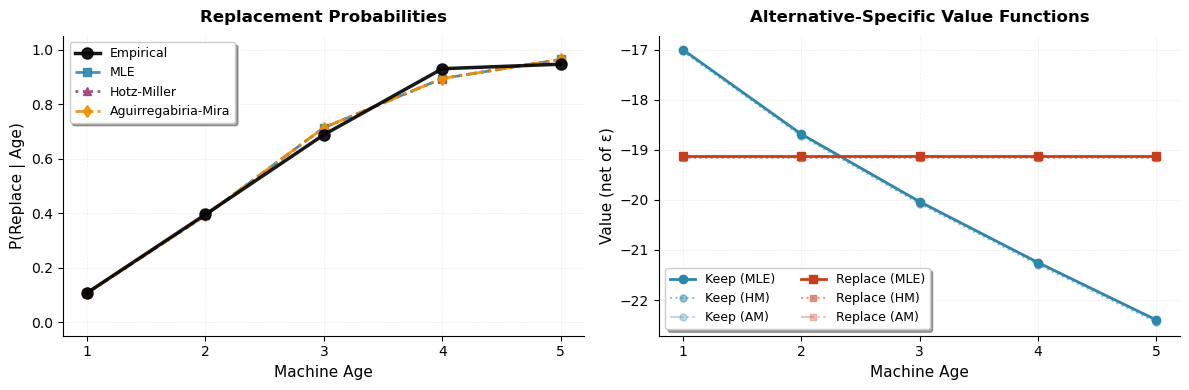

In [23]:
# Compute predicted probabilities and value functions
V0_mle, V1_mle = solve_dp(theta1_mle, R_mle)
probs_mle = compute_choice_probabilities(V0_mle, V1_mle)
V0_hm, V1_hm = solve_dp(theta1_hm, R_hm)
probs_hm = compute_choice_probabilities(V0_hm, V1_hm)
V0_am, V1_am = solve_dp(theta1_am, R_am)
probs_am = compute_choice_probabilities(V0_am, V1_am)

print("\n" + "="*135)
print("MODEL FIT AND VALUE FUNCTIONS: Empirical, MLE, Hotz-Miller (K=1), and Aguirregabiria-Mira (K=2)")
print("="*135)
print("\nAge | Empirical | MLE (Prob) | HM (Prob)  | AM (Prob)  |   V0_MLE   |    V0_HM   |    V0_AM   |   V1_MLE   |    V1_HM   |    V1_AM")
print("-"*135)
for a in range(N_STATES):
    print(f" {a+1}  | {p_empirical[a]:9.4f} | {probs_mle[a]:10.4f} | {probs_hm[a]:10.4f} | {probs_am[a]:10.4f} | {V0_mle[a]:10.4f} | {V0_hm[a]:10.4f} | {V0_am[a]:10.4f} | {V1_mle[a]:10.4f} | {V1_hm[a]:10.4f} | {V1_am[a]:10.4f}")
print("-"*135)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ages_plot = np.arange(1, 6)

# Left: Replacement Probabilities
ax0 = axes[0]
ax0.plot(ages_plot, p_empirical, 'o-', label='Empirical', lw=2.5, ms=8, color='black', zorder=4,  alpha=0.9)
ax0.plot(ages_plot, probs_mle, 's--', label='MLE', lw=2, ms=6, color='#2E86AB', alpha=0.9)
ax0.plot(ages_plot, probs_hm, '^:', label='Hotz-Miller', lw=2, ms=6, color='#A23B72', alpha=0.9)
ax0.plot(ages_plot, probs_am, 'd-.', label='Aguirregabiria-Mira', lw=2, ms=6, color='#F18F01', alpha=0.9)
ax0.set_xlabel('Machine Age', fontsize=11, fontweight='medium')
ax0.set_ylabel('P(Replace | Age)', fontsize=11, fontweight='medium')
ax0.set_title('Replacement Probabilities', fontsize=12, fontweight='bold', pad=10)
ax0.legend(fontsize=9, frameon=True, fancybox=True, shadow=True, loc='upper left')
ax0.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax0.set_ylim(-0.05, 1.05)
ax0.set_xticks(ages_plot)
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

# Right: Value Functions
ax1 = axes[1]
# Keep values (V0)
ax1.plot(ages_plot, V0_mle, 'o-', label='Keep (MLE)', lw=2, ms=6, color='#2E86AB')
ax1.plot(ages_plot, V0_hm, 'o:', label='Keep (HM)', lw=1.5, ms=5, color='#2E86AB', alpha=0.5)
ax1.plot(ages_plot, V0_am, 'o-.', label='Keep (AM)', lw=1.5, ms=5, color='#2E86AB', alpha=0.3)
# Replace values (V1)
ax1.plot(ages_plot, V1_mle, 's-', label='Replace (MLE)', lw=2, ms=6, color='#C73E1D')
ax1.plot(ages_plot, V1_hm, 's:', label='Replace (HM)', lw=1.5, ms=5, color='#C73E1D', alpha=0.5)
ax1.plot(ages_plot, V1_am, 's-.', label='Replace (AM)', lw=1.5, ms=5, color='#C73E1D', alpha=0.3)
ax1.set_xlabel('Machine Age', fontsize=11, fontweight='medium')
ax1.set_ylabel('Value (net of ε)', fontsize=11, fontweight='medium')
ax1.set_title('Alternative-Specific Value Functions', fontsize=12, fontweight='bold', pad=10)
ax1.legend(fontsize=9, frameon=True, fancybox=True, shadow=True, ncol=2, loc='lower left')
ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax1.set_xticks(ages_plot)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('estimation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Appendix

### A1: MPEC (Mathematical Programming with Equilibrium Constraints)

Instead of nested fixed-point iteration (inner loop solves $V = T(V,\theta)$ for each $\theta$), MPEC treats value functions as additional parameters with Bellman constraints.

**NFXP**
$$\max_{\theta} \mathcal{L}(\theta) \quad \text{where } V(\theta) \text{ solves } V = T(V,\theta)$$

**MPEC**
$$\max_{\theta, V_0, V_1} \mathcal{L}(\theta, V_0, V_1) \quad \text{subject to Bellman equations:}$$
$$V_0(a) = \theta_1 \cdot a + \beta \cdot EV(a, 0) \quad \forall a$$
$$V_1(a) = R + \beta \cdot EV(1, 1) \quad \forall a$$

where $EV(a,d) = \gamma + \ln[\exp(V_0(a')) + \exp(V_1(a'))]$ with $a'$ being the next state.


In [16]:
def mpec_objective(x, data):
    """
    MPEC objective: negative log-likelihood with V0, V1 as parameters.
    
    Parameters:
        x: [theta1, R, V0[0], V0[1], ..., V0[4], V1[0], V1[1], ..., V1[4]]
           Total: 2 + 5 + 5 = 12 parameters
    """
    theta1, R = x[0], x[1]
    V0 = x[2:7]
    V1 = x[7:12]
    
    # Compute choice probabilities from value functions
    p_replace = 1 / (1 + np.exp(V0 - V1))
    
    # Negative log-likelihood
    ages, choices = data[:, 0].astype(int) - 1, data[:, 1]
    p_obs = np.where(choices == 1, p_replace[ages], 1 - p_replace[ages])
    nll = -np.sum(np.log(np.clip(p_obs, 1e-15, 1)))
    
    return nll

def mpec_constraints(x):
    """
    Bellman equation constraints for MPEC.
    
    Returns residuals that should equal zero:
        V0(a) - [θ₁·a + β·EV(a,0)] = 0
        V1(a) - [R + β·EV(1,1)] = 0
    """
    theta1, R = x[0], x[1]
    V0 = x[2:7]
    V1 = x[7:12]
    
    # Compute expected values
    EV = np.zeros((5, 2))  # EV[age, action]
    for a in range(5):
        for d in range(2):
            next_state = state_transition(a, d)
            # EV = γ + ln[exp(V0) + exp(V1)]
            EV[a, d] = EULER + np.log(np.exp(V0[next_state]) + np.exp(V1[next_state]))
    
    # Bellman equation residuals
    residuals = np.zeros(10)
    
    # V0 constraints: V0(a) = θ₁·a + β·EV(a,0)
    for a in range(5):
        residuals[a] = V0[a] - (theta1 * (a + 1) + BETA * EV[a, 0])
    
    # V1 constraints: V1(a) = R + β·EV(a,1)
    for a in range(5):
        residuals[5 + a] = V1[a] - (R + BETA * EV[a, 1])
    
    return residuals

def mle_mpec(data, verbose=True):
    """
    MPEC estimation: Maximize likelihood subject to Bellman constraints.
    
    Returns: (theta, V0, V1, log_likelihood, success)
    """
    # Initial guess
    theta1_init, R_init = 0, 0
    V0_init, V1_init = solve_dp(theta1_init, R_init)
    
    x0 = np.concatenate([[theta1_init, R_init], V0_init, V1_init])
    
    if verbose:
        print("MPEC Estimation (12 parameters: θ₁, R, V0[5], V1[5])")
        print(f"Initial objective: {mpec_objective(x0, data):.2f}")
        print(f"Initial constraint violation: {np.linalg.norm(mpec_constraints(x0)):.2e}")
    
    # Define constraints
    constraints = NonlinearConstraint(
        mpec_constraints,
        lb=np.zeros(10),  # Bellman equations = 0
        ub=np.zeros(10),
        jac='2-point'
    )
    
    # Optimize
    t0 = time.time()
    result = minimize(
        mpec_objective,
        x0,
        args=(data,),
        method='SLSQP',  # Sequential Least Squares Programming
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500, 'disp': verbose}
    )
    elapsed = time.time() - t0
    
    if verbose:
        print(f"\nOptimization completed in {elapsed:.2f} seconds")
        print(f"Success: {result.success}")
        print(f"Final objective: {result.fun:.2f}")
        print(f"Final constraint violation: {np.linalg.norm(mpec_constraints(result.x)):.2e}")
    
    # Extract results
    theta1_mpec = result.x[0]
    R_mpec = result.x[1]
    V0_mpec = result.x[2:7]
    V1_mpec = result.x[7:12]
    ll_mpec = -result.fun
    
    return (theta1_mpec, R_mpec), (V0_mpec, V1_mpec), ll_mpec, result.success

# Run MPEC estimation
print("\n" + "="*70)
print("MPEC ESTIMATION")
print("="*70)
theta_mpec, (V0_mpec, V1_mpec), ll_mpec, success_mpec = mle_mpec(data, verbose=True)

# Compare with NFXP
print("\n" + "="*70)
print("NFXP vs MPEC Comparison")
print("="*0)
print(f"{'Method':<10} {'θ₁':<10} {'R':<10} {'LogLik':<10} {'||V0-V0_NFXP||':<15} {'||V1-V1_NFXP||':<15}")
print("-" * 60)
print(f"{'NFXP':<10} {theta1_mle:<10.4f} {R_mle:<10.4f} {log_lik_mle:<10.2f} {0.0:<15.2e} {0.0:<15.2e}")
V0_nfxp, V1_nfxp = solve_dp(theta1_mle, R_mle)
v0_diff = np.linalg.norm(V0_mpec - V0_nfxp)
v1_diff = np.linalg.norm(V1_mpec - V1_nfxp)
print(f"{'MPEC':<10} {theta_mpec[0]:<10.4f} {theta_mpec[1]:<10.4f} {ll_mpec:<10.2f} {v0_diff:<15.2e} {v1_diff:<15.2e}")
print("-" * 60)
print(f"\nParameter differences:")
print(f"  Δθ₁ = {abs(theta_mpec[0] - theta1_mle):.2e}")
print(f"  ΔR  = {abs(theta_mpec[1] - R_mle):.2e}")
print(f"  ΔLL = {abs(ll_mpec - log_lik_mle):.2e}")


MPEC ESTIMATION
MPEC Estimation (12 parameters: θ₁, R, V0[5], V1[5])
Initial objective: 693.15
Initial constraint violation: 1.38e-08
Optimization terminated successfully    (Exit mode 0)
            Current function value: 424.1588934091749
            Iterations: 14
            Function evaluations: 185
            Gradient evaluations: 14

Optimization completed in 0.01 seconds
Success: True
Final objective: 424.16
Final constraint violation: 8.65e-12

NFXP vs MPEC Comparison

Method     θ₁         R          LogLik     ||V0-V0_NFXP||  ||V1-V1_NFXP|| 
------------------------------------------------------------
NFXP       -1.1484    -4.4464    -424.16    0.00e+00        0.00e+00       
MPEC       -1.1484    -4.4464    -424.16    3.57e-05        3.53e-05       
------------------------------------------------------------

Parameter differences:
  Δθ₁ = 5.81e-07
  ΔR  = 2.53e-06
  ΔLL = 2.25e-11


### A2: Random Initial Values

In [17]:
num_guesses = 5
np.random.seed(1987)
initial_guesses = [np.random.uniform([-10, -10], [0, 0]) for _ in range(num_guesses)]

# MLE (using BFGS for sensitivity to initial values)
mle_results = []
for guess in initial_guesses:
    t0 = time.time()
    result = minimize(nfxp_nll, guess, args=(data,), method='BFGS')
    mle_results.append({
        'guess': guess,
        'theta1': result.x[0], 
        'R': result.x[1], 
        'loglik': -result.fun,
        'time': time.time() - t0
    })

# Hotz-Miller (using BFGS for sensitivity to initial values)
hm_results = []
for guess in initial_guesses:
    t0 = time.time()
    result = minimize(hotz_miller_nll, guess, args=(data, CCP, T), 
                      method='BFGS')
    hm_results.append({
        'guess': guess,
        'theta1': result.x[0], 
        'R': result.x[1], 
        'loglik': -result.fun,
        'time': time.time() - t0
    })
    
# Results Table
print(f"\n{'Initial [θ₁, R]':<18} {'MLE θ₁':>10} {'MLE R':>10} {'HM θ₁':>10} {'HM R':>9} {'Time HM/MLE':>14}")
print("-"*75)
for i in range(num_guesses):
    init_str = f"[{mle_results[i]['guess'][0]:5.2f},{mle_results[i]['guess'][1]:5.2f}]"
    rel_time = hm_results[i]['time'] / mle_results[i]['time']
    print(f"{init_str:<18} {mle_results[i]['theta1']:>10.4f} {mle_results[i]['R']:>10.4f} "
          f"{hm_results[i]['theta1']:>10.4f} {hm_results[i]['R']:>10.4f} {rel_time:>10.2f}")


Initial [θ₁, R]        MLE θ₁      MLE R      HM θ₁      HM R    Time HM/MLE
---------------------------------------------------------------------------
[-7.71,-9.31]         -1.1484    -4.4464    -1.1495    -4.4537       0.01
[-2.91,-2.66]         -1.1484    -4.4464    -1.1495    -4.4537       0.01
[-5.52,-9.45]         -1.1484    -4.4464    -1.1495    -4.4537       0.01
[-7.60,-6.39]         -1.1484    -4.4464    -1.1495    -4.4537       0.01
[-4.82,-8.29]         -1.1484    -4.4464    -1.1495    -4.4537       0.01


### A3: Bootstrap

In [18]:
def single_bootstrap(b, data, theta_hat, method, T=None, K=2):
    """Single bootstrap iteration"""
    n = len(data)
    np.random.seed(os.getpid() + b) 
    indices = np.random.choice(n, size=n, replace=True)
    data_b = data[indices]
    
    try:
        if method == 'MLE':
            result = minimize(nfxp_nll, theta_hat, args=(data_b,), 
                            method='L-BFGS-B',
                            )
        elif method == 'HM':
            ages_b, choices_b = data_b[:, 0].astype(int), data_b[:, 1].astype(int)
            P_b = np.array([choices_b[ages_b == a].mean() if (ages_b == a).sum() > 0 else 0.5 
                          for a in range(1, 6)])
            CCP_b = np.column_stack([1 - P_b, P_b])
            result = minimize(hotz_miller_nll, theta_hat, args=(data_b, CCP_b, T),
                            method='L-BFGS-B',
                            )
        else:  # AM
            ages_b, choices_b = data_b[:, 0].astype(int), data_b[:, 1].astype(int)
            P_b = np.array([choices_b[ages_b == a].mean() if (ages_b == a).sum() > 0 else 0.5 
                          for a in range(1, 6)])
            CCP_b = np.column_stack([1 - P_b, P_b])
            result = minimize(aguirregabiria_mira_nll, theta_hat, 
                            args=(data_b, CCP_b, T, K),
                            method='L-BFGS-B',
                            )
        return result.x if result.success else [np.nan, np.nan]
    except:
        return [np.nan, np.nan]

def bootstrap_est_parallel(data, theta_hat, method='MLE', B=1000, n_jobs=-1, K=2):
    """
    Parallel bootstrap with bias-corrected CI
    """
    print(f"Running {B} {method} bootstraps in parallel (n_jobs={n_jobs})...")
    
    # Run parallel bootstrap
    estimates = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(single_bootstrap)(b, data, theta_hat, method, 
                                 T if method in ['HM', 'AM'] else None, K) 
        for b in range(B)
    )
    
    estimates = np.array(estimates)
    valid = ~np.isnan(estimates).any(axis=1)
    return estimates[valid]

# Run parallel bootstraps
np.random.seed(1987)
theta_mle = np.array([theta1_mle, R_mle])
theta_hm = np.array([theta1_hm, R_hm])
theta_am = np.array([theta1_am, R_am])

start_time = time.time()
boot_mle = bootstrap_est_parallel(data, theta_mle, 'MLE', B=1000, n_jobs=-1)
mle_time = time.time() - start_time
print(f"NFXP MLE bootstrap time: {mle_time:.2f} seconds")

start_time = time.time()
boot_hm = bootstrap_est_parallel(data, theta_hm, 'HM', B=1000, n_jobs=-1)
hm_time = time.time() - start_time
print(f"HM bootstrap time: {hm_time:.2f} seconds")

start_time = time.time()
boot_am = bootstrap_est_parallel(data, theta_am, 'AM', B=1000, n_jobs=-1, K=2)
am_time = time.time() - start_time
print(f"AM bootstrap time: {am_time:.2f} seconds")

Running 1000 MLE bootstraps in parallel (n_jobs=-1)...
NFXP MLE bootstrap time: 28.97 seconds
Running 1000 HM bootstraps in parallel (n_jobs=-1)...
NFXP MLE bootstrap time: 28.97 seconds
Running 1000 HM bootstraps in parallel (n_jobs=-1)...
HM bootstrap time: 0.52 seconds
Running 1000 AM bootstraps in parallel (n_jobs=-1)...
HM bootstrap time: 0.52 seconds
Running 1000 AM bootstraps in parallel (n_jobs=-1)...
AM bootstrap time: 0.63 seconds
AM bootstrap time: 0.63 seconds


In [19]:
# Compute statistics with BCa (Bias-Corrected and Accelerated) CI
def get_stats_bca(boot, theta_hat, data, method, n_jobs=-1, K=2):
    """Compute BCa confidence intervals"""

    n_boot = len(boot)
    se = boot.std(axis=0, ddof=1)
    bias = boot.mean(axis=0) - theta_hat
    
    # BCa confidence intervals
    ci_bca = np.zeros((2, 2))
    print(f"Computing BCa confidence intervals in parallel (n_jobs={n_jobs})...")
    
    for i in range(2):
        # Bias correction factor (z0)
        p_below = np.mean(boot[:, i] < theta_hat[i])
        # Clip to avoid -inf/+inf from norm.ppf at boundaries
        p_below = np.clip(p_below, 1e-10, 1 - 1e-10)
        z0 = norm.ppf(p_below)
        
        # Acceleration factor (a) using parallel jackknife
        n = len(data)
        
        def single_jackknife(j, data, theta_hat, i, method, K):
            np.random.seed(os.getpid() + j)
            data_jack = np.delete(data, j, axis=0)
            try:
                if method == 'MLE':
                    result = minimize(nfxp_nll, theta_hat, args=(data_jack,),
                                    method='L-BFGS-B',
                                    )
                elif method == 'HM':
                    ages_j = data_jack[:, 0].astype(int)
                    choices_j = data_jack[:, 1].astype(int)
                    P_j = np.array([choices_j[ages_j == a].mean() if (ages_j == a).sum() > 0 
                                   else 0.5 for a in range(1, 6)])
                    CCP_j = np.column_stack([1 - P_j, P_j])
                    result = minimize(hotz_miller_nll, theta_hat, 
                                    args=(data_jack, CCP_j, T),
                                    method='L-BFGS-B',
                                    )
                else:  # AM
                    ages_j = data_jack[:, 0].astype(int)
                    choices_j = data_jack[:, 1].astype(int)
                    P_j = np.array([choices_j[ages_j == a].mean() if (ages_j == a).sum() > 0 
                                   else 0.5 for a in range(1, 6)])
                    CCP_j = np.column_stack([1 - P_j, P_j])
                    result = minimize(aguirregabiria_mira_nll, theta_hat, 
                                    args=(data_jack, CCP_j, T, K),
                                    method='L-BFGS-B',
                                    )
                return result.x[i] if result.success else theta_hat[i]
            except:
                return theta_hat[i]
        
        jack_estimates = np.array(Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(single_jackknife)(j, data, theta_hat, i, method, K) 
            for j in range(n)
        ))
        
        jack_mean = jack_estimates.mean()
        numerator = np.sum((jack_mean - jack_estimates)**3)
        denominator = 6 * (np.sum((jack_mean - jack_estimates)**2)**1.5)
        a = numerator / denominator if denominator != 0 else 0
        
        # Adjusted percentiles
        z_alpha = norm.ppf([0.025, 0.975])
        alpha_adj = norm.cdf(z0 + (z0 + z_alpha) / (1 - a * (z0 + z_alpha)))
        alpha_adj = np.clip(alpha_adj, 0.001, 0.999)
        
        ci_bca[i] = np.percentile(boot[:, i], 100 * alpha_adj)
    
    return se, bias, ci_bca


start_time = time.time()
se_mle, bias_mle, ci_bca_mle = get_stats_bca(boot_mle, theta_mle, data, 'MLE', n_jobs=-1)
mle_bca_time = time.time() - start_time
print(f"NFXP BCa time: {mle_bca_time:.2f} seconds")

# Save asymptotic SEs before they get overwritten
se_hm_asymp = se_hm.copy()
se_am_asymp = se_am.copy()

start_time = time.time()
se_hm_boot, bias_hm, ci_bca_hm = get_stats_bca(boot_hm, theta_hm, data, 'HM', n_jobs=-1)
hm_bca_time = time.time() - start_time
print(f"HM BCa time: {hm_bca_time:.2f} seconds")

start_time = time.time()
se_am_boot, bias_am, ci_bca_am = get_stats_bca(boot_am, theta_am, data, 'AM', n_jobs=-1, K=2)
am_bca_time = time.time() - start_time
print(f"AM BCa time: {am_bca_time:.2f} seconds")

Computing BCa confidence intervals in parallel (n_jobs=-1)...
NFXP BCa time: 47.55 seconds
Computing BCa confidence intervals in parallel (n_jobs=-1)...
NFXP BCa time: 47.55 seconds
Computing BCa confidence intervals in parallel (n_jobs=-1)...
HM BCa time: 0.90 seconds
Computing BCa confidence intervals in parallel (n_jobs=-1)...
HM BCa time: 0.90 seconds
Computing BCa confidence intervals in parallel (n_jobs=-1)...
AM BCa time: 0.96 seconds
AM BCa time: 0.96 seconds



BOOTSTRAP RESULTS (BCa 95% CI)
Method     Param  Estimate   Asymp SE   Boot SE    Boot Bias    BCa 95% CI          
------------------------------------------------------------------------------------------
NFXP MLE   θ₁     -1.1484    0.0760     0.0823     -0.0039      [-1.2967, -0.9927]  
NFXP MLE   R      -4.4464    0.3254     0.3451     -0.0233      [-5.1395, -3.8154]  
HM (K=1)   θ₁     -1.1495    0.0777     0.0793     -0.0046      [-1.3081, -1.0024]  
HM (K=1)   R      -4.4537    0.3319     0.3275     -0.0112      [-5.1328, -3.8481]  
AM (K=2)   θ₁     -1.1484    0.0772     0.0815     -0.0018      [-1.3096, -0.9985]  
AM (K=2)   R      -4.4464    0.3297     0.3427     -0.0074      [-5.2021, -3.8335]  
------------------------------------------------------------------------------------------


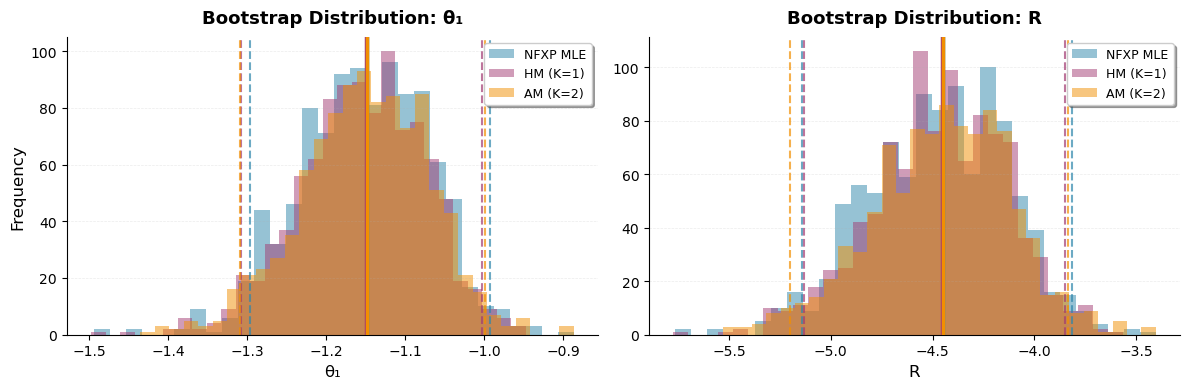

In [20]:
# Results
print("\n" + "="*90)
print("BOOTSTRAP RESULTS (BCa 95% CI)")
print("="*90)

print(f"{'Method':<10} {'Param':<6} {'Estimate':<10} {'Asymp SE':<10} {'Boot SE':<10} {'Boot Bias':<12} {'BCa 95% CI':<20}")
print("-"*90)

# MLE with asymptotic and bootstrap SE
for i, param in enumerate(['θ₁', 'R']):
    ci_str = f"[{ci_bca_mle[i,0]:.4f}, {ci_bca_mle[i,1]:.4f}]"
    print(f"{'NFXP MLE':<10} {param:<6} {theta_mle[i]:<10.4f} {se_hess[i]:<10.4f} {se_mle[i]:<10.4f} {bias_mle[i]:<12.4f} {ci_str:<20}")

# Hotz-Miller with bootstrap SE
for i, param in enumerate(['θ₁', 'R']):
    ci_str = f"[{ci_bca_hm[i,0]:.4f}, {ci_bca_hm[i,1]:.4f}]"
    asymp_se_str = f"{se_hm_asymp[i]:.4f}" if not np.isnan(se_hm_asymp[i]) else "N/A"
    print(f"{'HM (K=1)':<10} {param:<6} {theta_hm[i]:<10.4f} {asymp_se_str:<10} {se_hm_boot[i]:<10.4f} {bias_hm[i]:<12.4f} {ci_str:<20}")

# Aguirregabiria-Mira with bootstrap SE
for i, param in enumerate(['θ₁', 'R']):
    ci_str = f"[{ci_bca_am[i,0]:.4f}, {ci_bca_am[i,1]:.4f}]"
    asymp_se_str = f"{se_am_asymp[i]:.4f}" if not np.isnan(se_am_asymp[i]) else "N/A"
    print(f"{'AM (K=2)':<10} {param:<6} {theta_am[i]:<10.4f} {asymp_se_str:<10} {se_am_boot[i]:<10.4f} {bias_am[i]:<12.4f} {ci_str:<20}")

print("-"*90)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col, param in enumerate(['θ₁', 'R']):
    ax = axes[col]
    
    # MLE histogram
    ax.hist(boot_mle[:, col], bins=30, alpha=0.5, color='#2E86AB', 
            edgecolor='none', label='NFXP MLE', density=False)
    ax.axvline(theta_mle[col], color='#2E86AB', linewidth=2.5, zorder=10)
    ax.axvline(ci_bca_mle[col, 0], color='#2E86AB', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.axvline(ci_bca_mle[col, 1], color='#2E86AB', linewidth=1.5, linestyle='--', alpha=0.7)
    
    # HM histogram
    ax.hist(boot_hm[:, col], bins=30, alpha=0.5, color='#A23B72', 
            edgecolor='none', label='HM (K=1)', density=False)
    ax.axvline(theta_hm[col], color='#A23B72', linewidth=2.5, zorder=10)
    ax.axvline(ci_bca_hm[col, 0], color='#A23B72', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.axvline(ci_bca_hm[col, 1], color='#A23B72', linewidth=1.5, linestyle='--', alpha=0.7)
    
    # AM histogram
    ax.hist(boot_am[:, col], bins=30, alpha=0.5, color='#F18F01', 
            edgecolor='none', label='AM (K=2)', density=False)
    ax.axvline(theta_am[col], color='#F18F01', linewidth=2.5, zorder=10)
    ax.axvline(ci_bca_am[col, 0], color='#F18F01', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.axvline(ci_bca_am[col, 1], color='#F18F01', linewidth=1.5, linestyle='--', alpha=0.7)
    
    ax.set_xlabel(param, fontsize=12, fontweight='medium')
    ax.set_ylabel('Frequency' if col == 0 else '', fontsize=12, fontweight='medium')
    ax.set_title(f'Bootstrap Distribution: {param}', fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('bootstrap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### A4: Hypothesis Testing on $\beta$
Compare $\beta=0.9$ (baseline), $\beta=0.9999$ (patient agents), and $\beta=0$ (myopic agents) models using the normalized pointwise log-likelihood ratio: $V = \sqrt{n} \cdot \overline{LR}/\hat{\sigma}_{LR} \xrightarrow{d} N(0,1)$ under H₀ (models equidistant from truth). Rejecting H₀ at level $\alpha$ if $|V| > z_{\alpha/2}$ indicates one model is significantly closer to the data-generating process.

In [21]:
# Estimate models under different β assumptions
def ll_beta(theta1, R, data, beta):
    """Log-likelihood conditional on fixed β"""
    V0, V1 = solve_dp(theta1, R, beta=beta)
    p = 1/(1 + np.exp(V0 - V1))
    ages, choices = data[:, 0].astype(int) - 1, data[:, 1]
    p_obs = np.where(choices == 1, p[ages], 1 - p[ages])
    return np.sum(np.log(np.clip(p_obs, 1e-15, 1)))

models = {}
for beta_val, label in [(0.9, 'Baseline'), (0.9999, 'Patient'), (0.0, 'Myopic')]:
    t0 = time.time()
    if beta_val == 0.9:
        theta = np.array([theta1_mle, R_mle])
        loglik = ll_beta(theta1_mle, R_mle, data, beta_val)
    else:
        res = minimize(lambda p: -ll_beta(p[0], p[1], data, beta_val), 
                      x0=[theta1_mle, R_mle], method='BFGS')
        theta, loglik = res.x, ll_beta(res.x[0], res.x[1], data, beta_val)
    models[label] = {'β': beta_val, 'θ': theta, 'll': loglik, 't': time.time() - t0}

print(f"{'Model':<10} {'β':<8} {'θ₁':<10} {'R':<10} {'LogLik':<11} {'Time(s)':<8}")
print("-"*60)
for label in ['Baseline', 'Patient', 'Myopic']:
    m = models[label]
    print(f"{label:<10} {m['β']:<8.4f} {m['θ'][0]:<10.4f} {m['θ'][1]:<10.4f} {m['ll']:<11.2f} {m['t']:<8.3f}")

# Vuong (1989) test for non-nested model comparison
def vuong_test(ll1, ll2):
    """V = sqrt(n)*mean(LR)/std(LR) ~ N(0,1) under H0"""
    LR = ll1 - ll2
    return np.sqrt(len(LR)) * np.mean(LR) / np.std(LR, ddof=1)

def compute_pointwise_ll(theta1, R, data, beta):
    """Pointwise log-likelihoods"""
    V0, V1 = solve_dp(theta1, R, beta=beta)
    p = 1/(1 + np.exp(V0 - V1))
    ages, choices = data[:, 0].astype(int) - 1, data[:, 1]
    p_obs = np.where(choices == 1, p[ages], 1 - p[ages])
    return np.log(np.clip(p_obs, 1e-15, 1))

ll_baseline = compute_pointwise_ll(theta1_mle, R_mle, data, 0.9)
ll_patient = compute_pointwise_ll(models['Patient']['θ'][0], models['Patient']['θ'][1], data, 0.9999)
ll_myopic = compute_pointwise_ll(models['Myopic']['θ'][0], models['Myopic']['θ'][1], data, 0.0)

V_bp, V_bm, V_pm = vuong_test(ll_baseline, ll_patient), vuong_test(ll_baseline, ll_myopic), vuong_test(ll_patient, ll_myopic)
print(f"\nVuong: β=0.9 vs β=0.9999: V={V_bp:6.3f}, p={2*(1-norm.cdf(abs(V_bp))):.3f}")
print(f"Vuong: β=0.9 vs β=0:      V={V_bm:6.3f}, p={2*(1-norm.cdf(abs(V_bm))):.3f}")

Model      β        θ₁         R          LogLik      Time(s) 
------------------------------------------------------------
Baseline   0.9000   -1.1484    -4.4464    -424.16     0.006   
Patient    0.9999   -1.1246    -4.5950    -424.17     6.348   
Myopic     0.0000   -1.3833    -3.3137    -425.32     0.003   

Vuong: β=0.9 vs β=0.9999: V= 0.092, p=0.926
Vuong: β=0.9 vs β=0:      V= 0.705, p=0.481


### A5: Expected Replacement Demand Function

The expected number of replacements per period in the long-run stationary equilibrium is obtained by computing the stationary distribution over machine ages and averaging replacement probabilities. The stationary distribution $\pi^* \in \Delta^5$ satisfies the balance equation
$$\pi^*(a') = \sum_{a=1}^5 \pi^*(a) \cdot \mathbb{P}(a_{t+1} = a' \mid a_t = a; \theta)$$
where the state transition probabilities are determined by the optimal policy:
$$\mathbb{P}(a_{t+1} = a' \mid a_t = a; \theta) = \begin{cases}
p(a; \theta) & \text{if } a' = 1 \text{ (replacement)} \\
1 - p(a; \theta) & \text{if } a' = \min\{5, a+1\} \text{ (aging)} \\
0 & \text{otherwise}
\end{cases}$$
and $p(a; \theta) = [1 + \exp(V_0(a; \theta) - V_1(a; \theta))]^{-1}$ is the conditional replacement probability at age $a$. Equivalently, $\pi^*$ is the left eigenvector corresponding to eigenvalue 1 of the transition matrix $\mathbf{P}(\theta)$ with elements $P_{a'a}(\theta) = \mathbb{P}(a_{t+1} = a' \mid a_t = a; \theta)$.

The expected replacement demand function is then
$$Q(R; \theta_1, \beta) = \sum_{a=1}^5 \pi^*(a; \theta) \cdot p(a; \theta) = \mathbb{E}_{\pi^*}[p(a; \theta)]$$
which depends on the replacement cost $R$ both directly through the value functions $V_0(a; \theta)$ and $V_1(a; \theta)$ (affecting the conditional choice probabilities $p(a; \theta)$) and indirectly through the induced stationary distribution $\pi^*(a; \theta)$ over machine ages. 

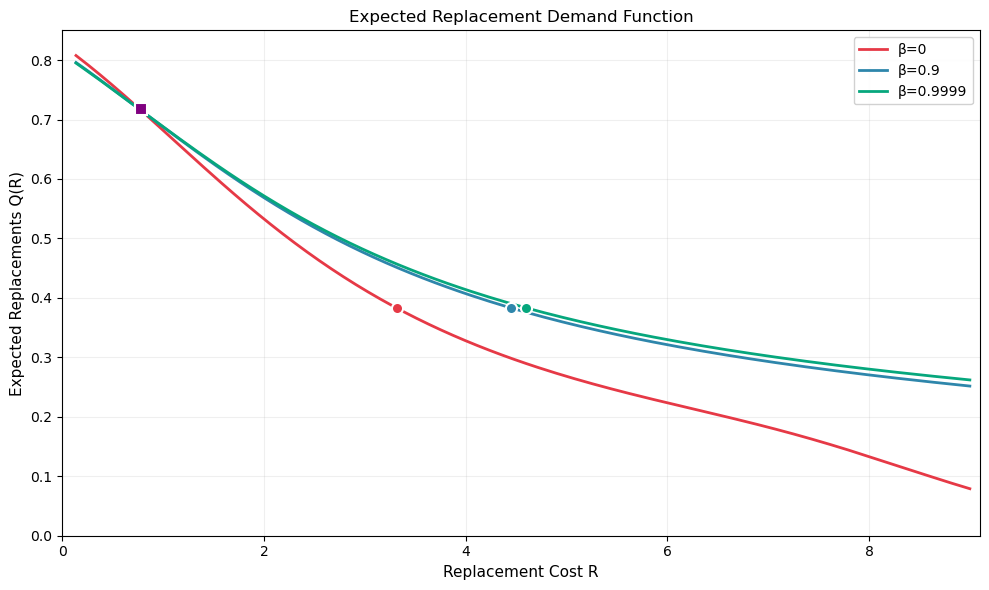

In [22]:
# Extract parameters from estimated models
theta1_beta0 = models['Myopic']['θ'][0]
R_beta0 = models['Myopic']['θ'][1]
theta1_beta9999 = models['Patient']['θ'][0]
R_beta9999 = models['Patient']['θ'][1]

def compute_stationary_distribution(V0, V1, max_iter=10000, tol=1e-10):
    """
    Compute stationary distribution π* over machine ages {1,2,3,4,5}.
    
    Uses power iteration: π_{t+1} = P π_t where P[i,j] = Pr(age_{t+1}=i+1 | age_t=j+1).
    Indexing: i,j ∈ {0,1,2,3,4} correspond to ages {1,2,3,4,5}.
    
    Args:
        V0, V1: Value functions for keep and replace decisions (arrays of length 5)
        max_iter: Maximum power iterations
        tol: Convergence tolerance
    
    Returns:
        π*: Stationary distribution over ages 1-5 (array of length 5, sums to 1)
    """
    # Compute conditional choice probabilities
    p_replace = 1 / (1 + np.exp(V0 - V1))
    
    # Build transition matrix P where P[i,j] = Pr(age_{t+1}=i+1 | age_t=j+1)
    P = np.zeros((5, 5))
    for idx in range(5):  # Current age index (0-4 for ages 1-5)
        # Replace: transition to age 1 (index 0)
        P[0, idx] = p_replace[idx]
        
        # Keep: age increases by 1 (or stays at 5)
        if idx < 4:  # Ages 1-4 transition to age+1
            P[idx + 1, idx] = 1 - p_replace[idx]
        else:  # Age 5 stays at age 5
            P[4, idx] = 1 - p_replace[idx]
    
    # Sanity check: each column should sum to 1
    assert np.allclose(P.sum(axis=0), 1.0), f"Transition matrix columns must sum to 1, got {P.sum(axis=0)}"
    
    # Power iteration to find stationary distribution
    pi = np.ones(5) / 5  # Start with uniform distribution
    for _ in range(max_iter):
        pi_new = P @ pi
        if np.max(np.abs(pi_new - pi)) < tol:
            break
        pi = pi_new
    
    return pi / pi.sum()  # Normalize (should already sum to 1)

def expected_replacements(theta1, R, beta=0.9):
    """
    Compute expected number of replacements per period in stationary equilibrium.
    
    Returns:
        Q(R) = Σ_a π*(a) * p(replace | a)
    """
    V0, V1 = solve_dp(theta1, R, beta=beta)
    p_replace = 1 / (1 + np.exp(V0 - V1))
    pi = compute_stationary_distribution(V0, V1)
    return np.sum(pi * p_replace)

# Compute demand curves for all three beta values
def expected_replacements_general(theta1, R, beta):
    """General wrapper for computing expected replacements at any beta."""
    V0, V1 = solve_dp(theta1, R, beta=beta)
    p_replace = 1 / (1 + np.exp(V0 - V1))
    pi = compute_stationary_distribution(V0, V1)
    return np.sum(pi * p_replace)

# Grid of replacement costs
R_grid = np.linspace(R_mle - 6, R_mle + 6, 200)

# Compute full demand curves (note: R is negative, so -R > 0 for plotting)
replacements_beta0_full = np.array([expected_replacements_general(theta1_beta0, R, 0.0) for R in R_grid])
replacements_beta90_full = np.array([expected_replacements_general(theta1_mle, R, 0.9) for R in R_grid])
replacements_beta9999_full = np.array([expected_replacements_general(theta1_beta9999, R, 0.9999) for R in R_grid])

# Find intersections between demand curves
def find_intersection(R_grid, Q1, Q2):
    """Find first intersection point between two demand curves."""
    diff = Q1 - Q2
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    if len(sign_changes) > 0:
        idx = sign_changes[0]
        # Linear interpolation for intersection
        R_int = R_grid[idx] + (R_grid[idx+1] - R_grid[idx]) * (-diff[idx]) / (diff[idx+1] - diff[idx])
        Q_int = (Q1[idx] + Q1[idx+1]) / 2
        return R_int, Q_int
    return None, None

R_int_0_90, Q_int_0_90 = find_intersection(R_grid, replacements_beta0_full, replacements_beta90_full)
R_int_90_9999, Q_int_90_9999 = find_intersection(R_grid, replacements_beta90_full, replacements_beta9999_full)

# Determine leftmost intersection point for plot range
if R_int_0_90 and R_int_90_9999:
    R_min_intersection = min(-R_int_0_90, -R_int_90_9999)
elif R_int_0_90:
    R_min_intersection = -R_int_0_90
elif R_int_90_9999:
    R_min_intersection = -R_int_90_9999
else:
    R_min_intersection = 1

# Filter to plot range: from R_start to 9
R_start = 0.1
R_mask = (-R_grid >= R_start) & (-R_grid <= 9)
R_grid_plot = R_grid[R_mask]
replacements_beta0 = replacements_beta0_full[R_mask]
replacements_beta90 = replacements_beta90_full[R_mask]
replacements_beta9999 = replacements_beta9999_full[R_mask]

# Equilibrium points
eq_beta0 = expected_replacements_general(theta1_beta0, R_beta0, 0.0)
eq_beta90 = expected_replacements_general(theta1_mle, R_mle, 0.9)
eq_beta9999 = expected_replacements_general(theta1_beta9999, R_beta9999, 0.9999)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(-R_grid_plot, replacements_beta0, '-', lw=2, color='#E63946', label='β=0')
ax.plot(-R_grid_plot, replacements_beta90, '-', lw=2, color='#2E86AB', label='β=0.9')
ax.plot(-R_grid_plot, replacements_beta9999, '-', lw=2, color='#06A77D', label='β=0.9999')
ax.plot(-R_beta0, eq_beta0, 'o', ms=8, color='#E63946', mec='white', mew=1.5)
ax.plot(-R_mle, eq_beta90, 'o', ms=8, color='#2E86AB', mec='white', mew=1.5)
ax.plot(-R_beta9999, eq_beta9999, 'o', ms=8, color='#06A77D', mec='white', mew=1.5)
if R_int_0_90: ax.plot(-R_int_0_90, Q_int_0_90, 'X', ms=10, color='black', mec='white', mew=1.5)
if R_int_90_9999: ax.plot(-R_int_90_9999, Q_int_90_9999, 's', ms=8, color='purple', mec='white', mew=1.5)
ax.set_xlabel('Replacement Cost R', fontsize=11)
ax.set_ylabel('Expected Replacements Q(R)', fontsize=11)
ax.set_title('Expected Replacement Demand Function', fontsize=12)
ax.set_xlim(0, 9.1)
ax.set_ylim(0, .85)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()